<h1 style="font-weight:900; color:#0E2841; margin:0.4em 0 0.2em;">Lerneinheit 2 · Die Suche von Hand und was sie kostet</h1>

<div style="font-size:0.8em; color:#5a6472; margin-top:-4px;">Version 1.0</div>

<span style="color:#5a6472; font-size:0.9em;">Tensor to GPU – Programmierkonzepte für KI · Prof. Dr. Stephan Kurpjuweit · Hochschule Worms · © 2026</span>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#E8B029; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Lernziele</div>
<div style="background:#FDF6E3; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Nach dieser Lerneinheit können Sie …</p>
<ul>
<li>die semantische Suche in reinem Python selbst implementieren und ihre Bausteine mit eigenen Tests absichern,</li>
<li>Daten und Verhalten in einer einfachen Klasse bündeln und vorbereitende Rechnungen wiederverwenden,</li>
<li>begründen, warum numerische Schleifen in reinem Python langsam sind, und Container nach ihren Zugriffskosten auswählen,</li>
<li>erklären, warum Ergebnisse mit Fließkommazahlen mit einer Toleranz verglichen werden.</li>
</ul>

</div>
</div>

In der letzten Lerneinheit lief die semantische Suche als fertige NumPy-Funktion, und Sie haben mit ihren Ergebnissen gearbeitet. Heute schreiben Sie die Rechnung dahinter selbst, in reinem Python und Schritt für Schritt. Danach bündeln Sie Daten und Funktionen in einer Klasse und untersuchen, warum diese Fassung so viel langsamer ist als NumPy. Auf der Landkarte stehen wir damit weiter auf der obersten Station, bei Python selbst.

Vorausgesetzt wird Teil 1 des Python-Grundkurses aus der letzten Lerneinheit. Tupel, Dictionaries und Sets führt dieses Notebook nur so weit ein, wie es sie braucht. In voller Breite behandelt sie Teil 2 des Grundkurses, den Sie im Anschluss an diesen Termin bearbeiten.

An mehreren Stellen stehen Boxen mit dem Titel „Vertiefung". Sie beantworten Fragen für alle, die es genau wissen wollen. Im Termin überspringen wir diese Boxen, und ihr Inhalt ist nicht prüfungsrelevant.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#E8B029; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Inhalt</div>
<div style="background:#FDF6E3; color:#1a1a1a; padding:12px 16px; margin:0;">
<ul style="margin:0; padding-left:1.2em;"><li style="margin:5px 0;">2.1&nbsp;&nbsp;<a href="#kap-aufwaermen" style="color:#1a1a1a; text-decoration:none; border-bottom:1px solid #E8B029;">Aufwärmen</a><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #475569; color:#475569; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M1</span></li><li style="margin:5px 0;">2.2&nbsp;&nbsp;<a href="#kap-container-in-kuerze" style="color:#1a1a1a; text-decoration:none; border-bottom:1px solid #E8B029;">Container in Kürze</a><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #475569; color:#475569; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M1</span></li><li style="margin:5px 0;">2.3&nbsp;&nbsp;<a href="#kap-die-suche-von-hand" style="color:#1a1a1a; text-decoration:none; border-bottom:1px solid #E8B029;">Die Suche von Hand</a><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #475569; color:#475569; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M1</span><ul style="margin:2px 0 0; padding-left:1.4em; font-size:0.92em; list-style:none;"><li style="margin:2px 0;">2.3.1&nbsp;&nbsp;<a href="#kap-die-laenge-eines-vektors" style="color:#1a1a1a; text-decoration:none;">Die Länge eines Vektors</a></li><li style="margin:2px 0;">2.3.2&nbsp;&nbsp;<a href="#kap-normalize" style="color:#1a1a1a; text-decoration:none;">Normalize</a></li><li style="margin:2px 0;">2.3.3&nbsp;&nbsp;<a href="#kap-compare-das-skalarprodukt" style="color:#1a1a1a; text-decoration:none;">Compare: das Skalarprodukt</a></li><li style="margin:2px 0;">2.3.4&nbsp;&nbsp;<a href="#kap-warum-normalisieren" style="color:#1a1a1a; text-decoration:none;">Warum normalisieren?</a></li><li style="margin:2px 0;">2.3.5&nbsp;&nbsp;<a href="#kap-select-alles-zusammensetzen" style="color:#1a1a1a; text-decoration:none;">Select: alles zusammensetzen</a></li></ul></li><li style="margin:5px 0;">2.4&nbsp;&nbsp;<a href="#kap-klassen-die-suche-als-objekt" style="color:#1a1a1a; text-decoration:none; border-bottom:1px solid #E8B029;">Klassen: die Suche als Objekt</a><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #475569; color:#475569; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M1</span></li><li style="margin:5px 0;">2.5&nbsp;&nbsp;<a href="#kap-was-kostet-python" style="color:#1a1a1a; text-decoration:none; border-bottom:1px solid #E8B029;">Was kostet Python?</a><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #B8860B; color:#B8860B; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M2</span><ul style="margin:2px 0 0; padding-left:1.4em; font-size:0.92em; list-style:none;"><li style="margin:2px 0;">2.5.1&nbsp;&nbsp;<a href="#kap-erst-schaetzen-dann-messen" style="color:#1a1a1a; text-decoration:none;">Erst schätzen, dann messen</a></li><li style="margin:2px 0;">2.5.2&nbsp;&nbsp;<a href="#kap-das-laufzeitmikroskop" style="color:#1a1a1a; text-decoration:none;">Das Laufzeitmikroskop</a></li><li style="margin:2px 0;">2.5.3&nbsp;&nbsp;<a href="#kap-was-kostet-ein-container" style="color:#1a1a1a; text-decoration:none;">Was kostet ein Container?</a></li></ul></li><li style="margin:5px 0;">2.6&nbsp;&nbsp;<a href="#kap-zahlen-im-rechner" style="color:#1a1a1a; text-decoration:none; border-bottom:1px solid #E8B029;">Zahlen im Rechner</a><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #B8860B; color:#B8860B; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M2</span></li></ul>

</div>
</div>

## <a id="kap-aufwaermen"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:3px solid #156082; padding-bottom:4px;  padding-top:26px;"><span style="float:right"><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #475569; color:#475569; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M1 · Python-Grundlagen</span></span>2.1&nbsp;&nbsp;Aufwärmen</span>

Drei kurze Schnipsel aus dem Stoff von Grundkurs Teil 1. Sagen Sie jeweils die Ausgabe vorher und führen Sie die Zelle erst danach aus.

<div style="border:2px solid #E97132; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#E97132; font-weight:bold; font-size:1.08em;">💭 Kurz überlegen</span></div>
<p>Was gibt die folgende Zelle aus?</p>

</div>

In [ ]:
total = 0
for x in [3, 4, 5]:
    if x > 3:
        total += x
print(total)

<div style="border:2px solid #E97132; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#E97132; font-weight:bold; font-size:1.08em;">💭 Kurz überlegen</span></div>
<p>Was gibt die folgende Zelle aus?</p>

</div>

In [ ]:
def double(x):
    print(x * 2)

y = double(4)
print(y)

<div style="border:2px solid #E97132; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#E97132; font-weight:bold; font-size:1.08em;">💭 Kurz überlegen</span></div>
<p>Was gibt die folgende Zelle aus?</p>

</div>

In [ ]:
a = [1, 2]
b = a
b.append(3)
print(a)

## <a id="kap-container-in-kuerze"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:3px solid #156082; padding-bottom:4px;  padding-top:26px;"><span style="float:right"><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #475569; color:#475569; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M1 · Python-Grundlagen</span></span>2.2&nbsp;&nbsp;Container in Kürze</span>

Die Kursdaten bestehen aus Listen, Tupeln und Dictionaries. Bevor wir rechnen, lernen Sie diese Container so weit kennen, dass Sie die Daten lesen können. Die nächsten beiden Zellen stellen die Daten bereit: dieselben 400 Wikipedia-Absätze mit ihren Vektoren und dieselben acht Beispielanfragen wie in der letzten Lerneinheit.

In [ ]:
# Kursdaten bereitstellen — nutzt data/, lädt Fehlendes aus dem Kursrepo nach
from pathlib import Path
from urllib.request import urlretrieve
for _name in ["appetizer_passages.json", "appetizer_embeddings.npy", "appetizer_queries.json", "appetizer_query_embeddings.npy"]:
    _ziel = Path("data") / _name
    if not _ziel.exists():
        _ziel.parent.mkdir(parents=True, exist_ok=True)
        try:
            urlretrieve("https://raw.githubusercontent.com/skuhswo/tensor-to-gpu-material/main/data/" + _name, _ziel)
        except Exception as _fehler:
            _ziel.unlink(missing_ok=True)          # keine halbe Datei zurücklassen
            _tipp = ""
            if "CERTIFICATE" in str(_fehler):      # Python von python.org auf dem Mac
                _tipp = (" Auf dem Mac zuerst 'Install Certificates.command' im Ordner "
                         "Programme/Python ausführen.")
            raise RuntimeError(f"{_ziel} fehlt und ließ sich nicht nachladen ({type(_fehler).__name__}). "
                               "Legen Sie den Ordner data/ aus dem ZIP der Lerneinheit neben dieses Notebook."
                               + _tipp) from None
    print(_ziel, "\u2713")

In [ ]:
# Vorgabe: Daten laden — einfach ausführen
import json, math, sys, time
import numpy as np      # heute nur zum Laden der Vektordateien und für einen Vergleich

with open("data/appetizer_passages.json", encoding="utf-8") as f:
    passages = json.load(f)["passages"]                                    # 400 Absätze
with open("data/appetizer_queries.json", encoding="utf-8") as f:
    queries = json.load(f)["queries"]                                      # 8 Beispielanfragen
vectors = np.load("data/appetizer_embeddings.npy").tolist()                # 400 Listen mit je 384 Zahlen
query_vectors = np.load("data/appetizer_query_embeddings.npy").tolist()    # 8 Listen mit je 384 Zahlen

print(len(passages), "Absätze,", len(vectors[0]), "Zahlen je Vektor,", len(queries), "Beispielanfragen")

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #3D7B7B; font-style: italic"># Vorgabe: Daten laden — einfach ausführen</span>
<span style="color: #008000; font-weight: bold">import</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">json</span><span style="color: #666">,</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">math</span><span style="color: #666">,</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">sys</span><span style="color: #666">,</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">time</span>
<span style="color: #008000; font-weight: bold">import</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">numpy</span><span style="color: #BBB"> </span><span style="color: #008000; font-weight: bold">as</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">np</span>      <span style="color: #3D7B7B; font-style: italic"># heute nur zum Laden der Vektordateien und für einen Vergleich</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; <code>with open(...) as f</code> öffnet die Datei und schließt sie am Ende des eingerückten Blocks wieder; <code>encoding=&quot;utf-8&quot;</code> legt die Zeichenkodierung fest, in der die Umlaute gespeichert sind</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000; font-weight: bold">with</span> <span style="color: #008000">open</span>(<span style="color: #BA2121">"data/appetizer_passages.json"</span>, encoding<span style="color: #666">=</span><span style="color: #BA2121">"utf-8"</span>) <span style="color: #008000; font-weight: bold">as</span> f:</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>②</b>&nbsp; <code>json.load(f)</code> liest den Inhalt der Datei und baut daraus Dicts und Listen</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>    passages <span style="color: #666">=</span> json<span style="color: #666">.</span>load(f)[<span style="color: #BA2121">"passages"</span>]                                    <span style="color: #3D7B7B; font-style: italic"># 400 Absätze</span>
<span style="color: #008000; font-weight: bold">with</span> <span style="color: #008000">open</span>(<span style="color: #BA2121">"data/appetizer_queries.json"</span>, encoding<span style="color: #666">=</span><span style="color: #BA2121">"utf-8"</span>) <span style="color: #008000; font-weight: bold">as</span> f:
    queries <span style="color: #666">=</span> json<span style="color: #666">.</span>load(f)[<span style="color: #BA2121">"queries"</span>]                                      <span style="color: #3D7B7B; font-style: italic"># 8 Beispielanfragen</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>③</b>&nbsp; <code>np.load</code> liest eine <code>.npy</code>-Datei als NumPy-Array, <code>.tolist()</code> macht daraus verschachtelte Python-Listen mit Python-Zahlen</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>vectors <span style="color: #666">=</span> np<span style="color: #666">.</span>load(<span style="color: #BA2121">"data/appetizer_embeddings.npy"</span>)<span style="color: #666">.</span>tolist()                <span style="color: #3D7B7B; font-style: italic"># 400 Listen mit je 384 Zahlen</span>
query_vectors <span style="color: #666">=</span> np<span style="color: #666">.</span>load(<span style="color: #BA2121">"data/appetizer_query_embeddings.npy"</span>)<span style="color: #666">.</span>tolist()    <span style="color: #3D7B7B; font-style: italic"># 8 Listen mit je 384 Zahlen</span>

<span style="color: #008000">print</span>(<span style="color: #008000">len</span>(passages), <span style="color: #BA2121">"Absätze,"</span>, <span style="color: #008000">len</span>(vectors[<span style="color: #666">0</span>]), <span style="color: #BA2121">"Zahlen je Vektor,"</span>, <span style="color: #008000">len</span>(queries), <span style="color: #BA2121">"Beispielanfragen"</span>)</code></pre></details>

Die Vektoren liegen in `.npy`-Dateien, dem Dateiformat von NumPy für Zahlenblöcke. Wie NumPy solche Blöcke speichert, ist Thema der nächsten Lerneinheit. Heute wandeln wir sie gleich beim Laden in Python-Listen um und rechnen ab hier ohne NumPy. `vectors` ist eine Liste aus 400 Listen, jede innere Liste ist der Vektor eines Absatzes. `vectors[0]` gehört zu `passages[0]`, `vectors[1]` zu `passages[1]` und so weiter. Für die Anfragen gilt dasselbe mit `query_vectors` und `queries`.

**Tupel.** Die Paare aus Titel und Ähnlichkeitswert, mit denen Sie im letzten Lab gearbeitet haben, heißen allgemein Tupel, hier sind es 2-Tupel. Ein Tupel fasst mehrere Werte zu einem festen Paket zusammen. Der Zugriff über die Position funktioniert wie bei einer Liste, ändern lässt sich ein Tupel nach dem Anlegen aber nicht mehr: Der Versuch `hit[1] = 0.9` endet mit einem `TypeError`. In C++ entsprechen dem `std::pair` und `std::tuple`.

In [ ]:
hit = ("San Diego", 0.831)             # ein Treffer: Titel und Ähnlichkeitswert
title, score = hit
print(title, score)
print(hit[0], len(hit))

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; runde Klammern mit Komma bilden ein Tupel</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>hit <span style="color: #666">=</span> (<span style="color: #BA2121">"San Diego"</span>, <span style="color: #666">0.831</span>)             <span style="color: #3D7B7B; font-style: italic"># ein Treffer: Titel und Ähnlichkeitswert</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>②</b>&nbsp; das Auspacken verteilt die Werte des Tupels auf zwei Namen, wie im letzten Lab</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>title, score <span style="color: #666">=</span> hit
<span style="color: #008000">print</span>(title, score)</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>③</b>&nbsp; der Zugriff über die Position und <code>len</code> funktionieren wie bei einer Liste</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(hit[<span style="color: #666">0</span>], <span style="color: #008000">len</span>(hit))</code></pre></details>

**Dictionary.** Ein Dictionary, kurz Dict, ordnet Schlüsseln Werte zu. Jeder Absatz der Kursdaten ist ein Dict mit den Schlüsseln `id`, `title` und `text`. Zugegriffen wird über den Schlüssel in eckigen Klammern. Fehlt der Schlüssel, bricht der Zugriff mit einem `KeyError` ab. In C++ entspricht dem `std::map`. Falls Sie damit schon gearbeitet haben, ist ein Unterschied wichtig: Dort legt `m[key]` bei einem fehlenden Schlüssel stillschweigend einen Eintrag an, in Python geschieht das beim Lesen nie.

In [ ]:
p = passages[0]                           # der erste Absatz der Kursdaten
print(p["title"])
print(list(p.keys()))
print("title" in p)
print(p.get("author", "unbekannt"))
my_hit = {"title": "San Diego", "score": 0.831}     # ein Treffer mit benannten Feldern
print(my_hit["score"])

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>p <span style="color: #666">=</span> passages[<span style="color: #666">0</span>]                           <span style="color: #3D7B7B; font-style: italic"># der erste Absatz der Kursdaten</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; der Schlüssel steht in eckigen Klammern, wie ein Index, nur mit Namen statt Position</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(p[<span style="color: #BA2121">"title"</span>])</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>②</b>&nbsp; <code>keys()</code> liefert alle Schlüssel eines Dicts, <code>list(...)</code> macht daraus eine Liste</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(<span style="color: #008000">list</span>(p<span style="color: #666">.</span>keys()))</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>③</b>&nbsp; <code>in</code> prüft bei einem Dict, ob es den Schlüssel gibt</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(<span style="color: #BA2121">"title"</span> <span style="color: #A2F; font-weight: bold">in</span> p)</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>④</b>&nbsp; <code>get</code> liefert bei einem fehlenden Schlüssel den angegebenen Ersatzwert statt eines Fehlers</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(p<span style="color: #666">.</span>get(<span style="color: #BA2121">"author"</span>, <span style="color: #BA2121">"unbekannt"</span>))</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>⑤</b>&nbsp; geschweifte Klammern mit <code>Schlüssel: Wert</code> legen ein eigenes Dict an</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>my_hit <span style="color: #666">=</span> {<span style="color: #BA2121">"title"</span>: <span style="color: #BA2121">"San Diego"</span>, <span style="color: #BA2121">"score"</span>: <span style="color: #666">0.831</span>}     <span style="color: #3D7B7B; font-style: italic"># ein Treffer mit benannten Feldern</span>
<span style="color: #008000">print</span>(my_hit[<span style="color: #BA2121">"score"</span>])</code></pre></details>

<div style="border:2px solid #7E3FA0; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; ">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#7E3FA0; font-weight:bold; font-size:1.08em;">Lernfragen 2.2 #1</span></div>
<p style="padding-left:1.2em; text-indent:-1.2em;"><b style="color:#7E3FA0;">1.</b> Der erste Absatz hat den Titel „Aufzugsanlage". Welche der beiden Prüfungen liefert <code>True</code>: <code>"title" in passages[0]</code> oder <code>"Aufzugsanlage" in passages[0]</code>? Begründen Sie Ihre Antwort.</p>

</div>

**Set.** Ein Set ist eine Menge: Jeder Wert kommt darin höchstens einmal vor, und eine Reihenfolge gibt es nicht. Damit lassen sich Duplikate entfernen. Die nächste Zelle sammelt die Titel aller Absätze und bildet daraus ein Set. Das Ergebnis korrigiert nebenbei eine Aussage aus der letzten Lerneinheit: Die 400 Absätze stammen nicht aus 400 verschiedenen Artikeln, manche Artikel sind mit mehreren Absätzen vertreten.

In [ ]:
titles = []
for p in passages:
    titles.append(p["title"])             # die Titel aller 400 Absätze
unique_titles = set(titles)
print(len(titles), "Absätze aus", len(unique_titles), "verschiedenen Artikeln")
print("San Diego" in unique_titles)

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>titles <span style="color: #666">=</span> []
<span style="color: #008000; font-weight: bold">for</span> p <span style="color: #A2F; font-weight: bold">in</span> passages:
    titles<span style="color: #666">.</span>append(p[<span style="color: #BA2121">"title"</span>])             <span style="color: #3D7B7B; font-style: italic"># die Titel aller 400 Absätze</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; <code>set(...)</code> bildet aus einer Liste ein Set, Duplikate fallen dabei weg</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>unique_titles <span style="color: #666">=</span> <span style="color: #008000">set</span>(titles)
<span style="color: #008000">print</span>(<span style="color: #008000">len</span>(titles), <span style="color: #BA2121">"Absätze aus"</span>, <span style="color: #008000">len</span>(unique_titles), <span style="color: #BA2121">"verschiedenen Artikeln"</span>)</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>②</b>&nbsp; auch bei einem Set prüft <code>in</code>, ob ein Wert enthalten ist</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(<span style="color: #BA2121">"San Diego"</span> <span style="color: #A2F; font-weight: bold">in</span> unique_titles)</code></pre></details>

<div style="border:2px solid #475569; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#475569; font-weight:bold; font-size:1.08em;">Überblick: Vier Container</span></div>
<p>Liste, Tupel, Dict und Set sind vier häufig verwendete eingebaute Container von Python. Dieses Notebook nutzt von jedem nur das Nötigste, die volle Breite folgt in Grundkurs Teil 2.</p>
<p>Veränderlich heißt: Nach dem Anlegen lassen sich Elemente hinzufügen, ersetzen oder entfernen.</p>
<table>
<thead>
<tr>
<th>Container</th>
<th>Beispiel</th>
<th>Zugriff</th>
<th>veränderlich?</th>
<th>typischer Einsatz</th>
</tr>
</thead>
<tbody>
<tr>
<td>Liste</td>
<td><code style="white-space:nowrap">[0.2, 0.9, 0.4]</code></td>
<td>über die Position: <code>xs[0]</code></td>
<td>ja, zum Beispiel <code style="white-space:nowrap">xs.append(0.7)</code></td>
<td>geordnete Folge von Werten, meist gleichartig. Beispiele: die Einträge eines Vektors, alle Absätze des Korpus</td>
</tr>
<tr>
<td>Tupel</td>
<td><code style="white-space:nowrap">("Gehirn", 0.9)</code></td>
<td>über die Position: <code>hit[0]</code>, oder durch Auspacken: <code style="white-space:nowrap">title, score = hit</code></td>
<td>nein</td>
<td>festes Paket zusammengehöriger Werte. Beispiel: ein Treffer aus Titel und Ähnlichkeitswert</td>
</tr>
<tr>
<td>Dict</td>
<td><code style="white-space:nowrap">{"title": "Gehirn"}</code></td>
<td>über den Schlüssel: <code>p["title"]</code></td>
<td>ja, zum Beispiel <code style="white-space:nowrap">p["lang"] = "de"</code></td>
<td>benannte Felder und Zuordnungen. Beispiel: ein Absatz mit <code>id</code>, <code>title</code> und <code>text</code></td>
</tr>
<tr>
<td>Set</td>
<td><code style="white-space:nowrap">{"Gehirn", "Zeit"}</code></td>
<td>kein Zugriff auf ein einzelnes Element. Möglich sind die Prüfung <code style="white-space:nowrap">"Zeit" in s</code> und das Durchlaufen mit <code>for</code></td>
<td>ja, zum Beispiel <code style="white-space:nowrap">s.add("Mali")</code></td>
<td>Duplikate entfernen und schnell prüfen, ob ein Wert vorkommt. Beispiel: die verschiedenen Titel des Korpus</td>
</tr>
</tbody>
</table>
<p>Eine Liste darf Werte verschiedener Typen mischen. Üblich sind Listen mit gleichartigen Werten.</p>

</div>

Damit lassen sich die Kursdaten vollständig lesen. Die Abbildung zeigt, wie sie zusammenhängen: Jede Anfrage nennt unter `expected` die Nummer des Absatzes, der gefunden werden soll. Absatz und Vektor stehen in `passages` und `vectors` jeweils unter demselben Index.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">5 min</span>✏️ Aufgabe 2.2 #1</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Jede Beispielanfrage nennt im Feld <code>expected</code> die Nummer des Absatzes, der gefunden werden soll. Schreiben Sie die Funktion <code>expected_title(query_no)</code>. Sie gibt zu einer Anfragenummer (0 bis 7) den Titel dieses Absatzes zurück. Sehen Sie sich dazu zuerst <code>queries[0]</code> in einer eigenen Zelle an.</p>
<p>Wer früher fertig ist: Geben Sie in einer Schleife für alle acht Anfragen den Fragetext und den erwarteten Titel aus.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> Es sind zwei Zugriffe nacheinander. Erst liefert <code>queries[query_no]["expected"]</code> die Nummer des Absatzes, dann führt diese Nummer in <code>passages</code> zum Absatz und dessen Titel.</p></div></details>
</div>
</div>

In [ ]:
def expected_title(query_no):
    # TODO: Ihre Lösung hier
    ...

In [ ]:
# Prüfzelle — einfach ausführen
assert expected_title(0) == "San Diego", "Anfrage 0 fragt nach San Diego"
assert expected_title(3) == "Gehirn", "Anfrage 3 fragt nach dem Gehirn"
assert expected_title(7) == passages[queries[7]["expected"]]["title"]
print("Alle Prüfungen bestanden ✓")

## <a id="kap-die-suche-von-hand"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:3px solid #156082; padding-bottom:4px;  padding-top:26px;"><span style="float:right"><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #475569; color:#475569; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M1 · Python-Grundlagen</span></span>2.3&nbsp;&nbsp;Die Suche von Hand</span>

<div style="border:2px solid #156082; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#156082; font-weight:bold; font-size:1.08em;">🔄 Wiederholung: Normalize, Compare, Select</span></div>
<p>Die Suche vergleicht den Vektor der Anfrage mit den Vektoren aller Absätze, in drei Schritten. <strong>Normalize</strong> bringt alle Vektoren auf die Länge 1. <strong>Compare</strong> berechnet das Skalarprodukt der Anfrage mit jedem Absatz. <strong>Select</strong> wählt die höchsten Werte aus. Eingeführt wurde das in LE 1, Abschnitt 1.1.1.</p>

</div>

In der letzten Lerneinheit erledigte NumPy diese Rechnung in zwei Zeilen. Jetzt schreiben Sie jeden Baustein selbst, mit Listen, Schleifen und Funktionen. Für alle Funktionen dieses Kapitels gilt: Ein Vektor ist eine Liste von Zahlen. Zwei Vektoren, die miteinander verrechnet werden, haben gleich viele Einträge. Wo durch eine Länge geteilt wird, setzen wir Vektoren mit positiver Länge voraus. Den Nullvektor nehmen wir uns im Kapitel <a href="#kap-zahlen-im-rechner">2.6</a> vor.

### <a id="kap-die-laenge-eines-vektors"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:1px solid rgba(21,96,130,0.45); padding-bottom:2px;  padding-top:16px;">2.3.1&nbsp;&nbsp;Die Länge eines Vektors</span>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#0E2841; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Länge eines Vektors</div>
<div style="background:#E9EDF4; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Die Länge eines Vektors v mit n Einträgen ist die Wurzel aus der Summe der Quadrate seiner Einträge:</p>
<p>$$\Vert v \Vert = \sqrt{v_1^2 + v_2^2 + \dots + v_n^2}$$</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#0E2841; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #0E284155"><p>Das ist der Satz des Pythagoras, verallgemeinert auf n Dimensionen. Der Vektor (3, 4) hat die Länge 5, denn 9 + 16 = 25. In Grundkurs Teil 1 haben Sie dieselbe Rechnung für zwei Dimensionen mit <code>math.sqrt</code> geschrieben.</p></div></details>
</div>
</div>

**Prüfzellen mit Fließkommazahlen.** Rechnungen mit Fließkommazahlen liefern nicht immer exakt den erwarteten Wert, die letzte Nachkommastelle kann abweichen. Die Prüfzellen dieses Notebooks vergleichen solche Ergebnisse deshalb nicht mit `==`. Sie prüfen, ob der Abstand zum Sollwert sehr klein ist: `abs(actual - expected) < 1e-9`. Dabei liefert `abs` den Betrag einer Zahl, und `1e-9` ist die Schreibweise für 0,000000001. Woher die Abweichungen kommen, klärt das Kapitel <a href="#kap-zahlen-im-rechner">2.6</a>.

**Anschlusslösungen.** Die Aufgaben dieses Notebooks bauen aufeinander auf. Unter den Prüfzellen steht deshalb jeweils ein Aufklappfeld „Anschlusslösung" mit einer lauffähigen Fassung. Wenn Ihre eigene Lösung nach der Besprechung noch nicht läuft, kopieren Sie diese Fassung in Ihre Aufgabenzelle und führen die Zelle aus. So können Sie ohne Lücke weiterarbeiten.

Das Wort „Länge" hat ab jetzt zwei Bedeutungen. `len([3, 4])` liefert die Anzahl der Einträge, also 2. `norm([3, 4])` liefert die geometrische Länge, also 5. Beim Normalisieren ändert sich nur die geometrische Länge, die Anzahl der Einträge bleibt gleich.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">5 min</span>✏️ Aufgabe 2.3.1 #1</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Schreiben Sie die Funktion <code>norm(v)</code>. Sie gibt die Länge des Vektors <code>v</code> zurück. Die Eingabeliste bleibt unverändert.</p>
<p>Wer früher fertig ist: Prüfen Sie Ihre Funktion mit einem eigenen Beispiel. Wählen Sie dazu einen Vektor mit drei Einträgen, dessen Länge Sie von Hand ausrechnen können, zum Beispiel <code>[2.0, 3.0, 6.0]</code> (4 + 9 + 36 = 49, die Länge ist also 7). Schreiben Sie in eine neue Zelle eine <code>assert</code>-Zeile nach dem Muster der Prüfzelle.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> Summieren Sie in einer Schleife die Quadrate aller Elemente in einer Variablen, die mit <code>0.0</code> beginnt. Die Wurzel liefert <code>math.sqrt</code>.</p></div></details>
</div>
</div>

In [ ]:
def norm(v):
    # TODO: Ihre Lösung hier
    ...

In [ ]:
# Prüfzelle — einfach ausführen
assert norm([3.0, 4.0]) == 5.0, "3, 4 und 5 bilden ein rechtwinkliges Dreieck"
assert norm([0.0, 0.0]) == 0.0, "der Nullvektor hat die Länge 0"
assert norm([-2.0]) == 2.0, "das Vorzeichen fällt durch das Quadrieren weg"
assert abs(norm([1.0, 1.0]) - 1.4142135623730951) < 1e-9, "Wurzel aus 2"
_v = [1.0, 2.0, 2.0]
assert norm(_v) == 3.0
assert _v == [1.0, 2.0, 2.0], "die Eingabeliste darf nicht verändert werden"
assert abs(norm(vectors[0]) - 2.980013441153241) < 1e-9, "Länge des ersten Absatzvektors"
print("Alle Prüfungen bestanden ✓")

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Anschlusslösung zu norm</summary><div style="color:#475569; margin:6px 0 4px;">Wenn Ihre eigene Lösung nach der Besprechung noch nicht läuft: Kopieren Sie diese Fassung in Ihre Aufgabenzelle und führen Sie die Zelle aus.</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.9em; line-height:1.4; overflow-x:auto;">def norm(v):&#10;    total = 0.0&#10;    for x in v:&#10;        total += x * x&#10;    return math.sqrt(total)</pre></details>

### <a id="kap-normalize"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:1px solid rgba(21,96,130,0.45); padding-bottom:2px;  padding-top:16px;">2.3.2&nbsp;&nbsp;Normalize</span>

Normalisieren heißt, jeden Eintrag durch die Länge des Vektors zu teilen. Der Ergebnisvektor zeigt in dieselbe Richtung und hat die Länge 1. Ein Vektor der Länge 1 heißt Einheitsvektor. Die Funktion baut eine neue Liste auf und lässt die Eingabe unverändert. Das ist der Rumpf von `normalize_python` aus der letzten Lerneinheit, nur für einen einzelnen Vektor.

In [ ]:
def normalize(v):
    length = norm(v)
    result = []
    for x in v:
        result.append(x / length)      # jeden Eintrag durch die Länge teilen
    return result                      # neue Liste, v bleibt unverändert

print(normalize([3.0, 4.0]))
print(norm(normalize([3.0, 4.0])))

Die folgende Fassung stammt von einem KI-Assistenten. Sie liefert für `[3.0, 4.0]` dasselbe Ergebnis wie `normalize`. Die Anforderung lautet: Die Funktion gibt eine neue Liste zurück, die Eingabe bleibt unverändert.

<div style="border:2px solid #7E3FA0; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; ">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#7E3FA0; font-weight:bold; font-size:1.08em;">Lernfragen 2.3.2 #1</span></div>
<p style="padding-left:1.2em; text-indent:-1.2em;"><b style="color:#7E3FA0;">1.</b> Erfüllt <code>normalize_b</code> in der Zelle darunter diese Anforderung? Belegen Sie Ihr Urteil mit einem Test, den Sie in der Zelle ergänzen.</p>

</div>

In [ ]:
def normalize_b(v):
    length = norm(v)
    for i in range(len(v)):
        v[i] = v[i] / length
    return v

# Platz für Ihren Test:


### <a id="kap-compare-das-skalarprodukt"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:1px solid rgba(21,96,130,0.45); padding-bottom:2px;  padding-top:16px;">2.3.3&nbsp;&nbsp;Compare: das Skalarprodukt</span>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#0E2841; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Skalarprodukt und Kosinus-Ähnlichkeit</div>
<div style="background:#E9EDF4; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Das Skalarprodukt zweier Vektoren mit gleich vielen Einträgen multipliziert die Einträge paarweise und summiert die Produkte:</p>
<p>$$a \cdot b = a_1 b_1 + a_2 b_2 + \dots + a_n b_n$$</p>
<p>Die Kosinus-Ähnlichkeit teilt das Skalarprodukt durch die Längen beider Vektoren:</p>
<p>$$\cos(\theta) = \frac{a \cdot b}{\Vert a \Vert \, \Vert b \Vert}$$</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#0E2841; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #0E284155"><p>Haben beide Vektoren die Länge 1, ist der Nenner 1, und das Skalarprodukt ist bereits die Kosinus-Ähnlichkeit. Deshalb normalisiert die Suche zuerst und vergleicht dann nur noch mit dem Skalarprodukt.</p></div></details>
</div>
</div>

Für das Skalarprodukt laufen zwei Listen im Gleichschritt. Hier ist die Schleife über den Index der passende Weg: `a[i]` und `b[i]` gehören zusammen.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">5 min</span>✏️ Aufgabe 2.3.3 #1</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Schreiben Sie die Funktion <code>dot(a, b)</code>. Sie gibt das Skalarprodukt zweier Vektoren mit gleich vielen Einträgen zurück. Schreiben Sie danach die Funktion <code>cosine(a, b)</code>, die daraus mit <code>norm</code> die Kosinus-Ähnlichkeit berechnet.</p>
<p>Wer früher fertig ist: Jeder Vektor zeigt in dieselbe Richtung wie er selbst. Überlegen Sie, welchen Wert <code>cosine(v, v)</code> deshalb liefern muss, und prüfen Sie es in einer neuen Zelle mit <code>print(cosine(vectors[0], vectors[0]))</code>.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> <code>dot</code> ist wie <code>norm</code> aufgebaut, nur läuft die Schleife über <code>range(len(a))</code> und addiert <code>a[i] * b[i]</code>. <code>cosine</code> braucht keine eigene Schleife.</p></div></details>
</div>
</div>

In [ ]:
def dot(a, b):
    # TODO: Ihre Lösung hier
    ...

def cosine(a, b):
    # TODO: Ihre Lösung hier
    ...

In [ ]:
# Prüfzelle — einfach ausführen
assert dot([1.0, 2.0, 3.0], [4.0, 5.0, 6.0]) == 32.0, "4 + 10 + 18"
assert dot([1.0, 0.0], [0.0, 1.0]) == 0.0, "senkrechte Vektoren haben das Skalarprodukt 0"
assert abs(cosine([2.0, 0.0], [5.0, 0.0]) - 1.0) < 1e-9, "gleiche Richtung ergibt 1"
assert abs(cosine([1.0, 0.0], [0.0, 3.0]) - 0.0) < 1e-9, "senkrecht ergibt 0"
assert abs(cosine([1.0, 2.0], [-1.0, -2.0]) + 1.0) < 1e-9, "entgegengesetzte Richtung ergibt -1"
# die Spielzeugvektoren aus der letzten Lerneinheit
dog = [0.70, -0.20, 0.50, 0.90]
cat = [0.55, -0.10, 0.65, 0.90]
car = [0.10, 0.70, -0.20, 0.30]
assert abs(cosine(dog, cat) - 0.9825573682516039) < 1e-9, "Hund und Katze: rund 0.98"
assert abs(cosine(dog, car) - 0.09991510822169683) < 1e-9, "Hund und Auto: rund 0.10"
print("Alle Prüfungen bestanden ✓")

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Anschlusslösung zu dot und cosine</summary><div style="color:#475569; margin:6px 0 4px;">Wenn Ihre eigene Lösung nach der Besprechung noch nicht läuft: Kopieren Sie diese Fassung in Ihre Aufgabenzelle und führen Sie die Zelle aus.</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.9em; line-height:1.4; overflow-x:auto;">def dot(a, b):&#10;    total = 0.0&#10;    for i in range(len(a)):&#10;        total += a[i] * b[i]&#10;    return total&#10;&#10;def cosine(a, b):&#10;    return dot(a, b) / (norm(a) * norm(b))</pre></details>

Wenn zwei Listen im Gleichschritt durchlaufen werden, geht es in Python auch ohne Index. `zip` liefert die Elemente beider Listen paarweise. Beide Fassungen sind in Ordnung, mehr zu `zip` steht in Grundkurs Teil 2.

In [ ]:
def dot_zip(a, b):
    total = 0.0
    for x, y in zip(a, b):
        total += x * y
    return total

print(dot([1.0, 2.0, 3.0], [4.0, 5.0, 6.0]), dot_zip([1.0, 2.0, 3.0], [4.0, 5.0, 6.0]))

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000; font-weight: bold">def</span><span style="color: #BBB"> </span><span style="color: #00F">dot_zip</span>(a, b):
    total <span style="color: #666">=</span> <span style="color: #666">0.0</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; <code>zip(a, b)</code> liefert bei jedem Durchlauf ein Paar aus je einem Element beider Listen, das die Schleife gleich in <code>x</code> und <code>y</code> auspackt</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>    <span style="color: #008000; font-weight: bold">for</span> x, y <span style="color: #A2F; font-weight: bold">in</span> <span style="color: #008000">zip</span>(a, b):
        total <span style="color: #666">+=</span> x <span style="color: #666">*</span> y
    <span style="color: #008000; font-weight: bold">return</span> total

<span style="color: #008000">print</span>(dot([<span style="color: #666">1.0</span>, <span style="color: #666">2.0</span>, <span style="color: #666">3.0</span>], [<span style="color: #666">4.0</span>, <span style="color: #666">5.0</span>, <span style="color: #666">6.0</span>]), dot_zip([<span style="color: #666">1.0</span>, <span style="color: #666">2.0</span>, <span style="color: #666">3.0</span>], [<span style="color: #666">4.0</span>, <span style="color: #666">5.0</span>, <span style="color: #666">6.0</span>]))</code></pre></details>

### <a id="kap-warum-normalisieren"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:1px solid rgba(21,96,130,0.45); padding-bottom:2px;  padding-top:16px;">2.3.4&nbsp;&nbsp;Warum normalisieren?</span>

Ein Experiment mit vier Vektoren in zwei Dimensionen. Die Anfrage hat den Vektor `q = [1, 1]`. Der Vektor von Dokument A zeigt exakt in dieselbe Richtung wie `q`. Der Vektor von Dokument B ist lang und zeigt um 45 Grad daneben. Der Vektor von Dokument C steht senkrecht auf `q`. Überlegen Sie vor dem Ausführen: Welches Dokument bekommt den höchsten Wert, wenn wir nur das Skalarprodukt berechnen, ohne zu normalisieren?

In [ ]:
q = [1.0, 1.0]
docs = [("A", [1.0, 1.0]), ("B", [10.0, 0.0]), ("C", [0.5, -0.5])]
for name, d in docs:
    print(f"{name}   Skalarprodukt: {dot(q, d):5.1f}   Kosinus: {cosine(q, d):.2f}")

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E75B6; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Richtung statt Länge</div>
<div style="background:#EAF2FA; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Beim rohen Skalarprodukt gewinnt Dokument B allein durch die Länge seines Vektors, obwohl der Vektor von A exakt in die Richtung des Anfragevektors zeigt. Mit der Kosinus-Ähnlichkeit zählt nur die Richtung, und A liegt vorn. Unsere Suche vergleicht die Richtungen der Embeddings, ihre Länge soll den Vergleich nicht beeinflussen. Deshalb gehört das Normalisieren dazu.</p>
<p>Andere Modelle und Suchverfahren können andere Ähnlichkeitsmaße verwenden, zum Beispiel das Skalarprodukt ohne Normalisierung oder den euklidischen Abstand.</p>

</div>
</div>

Wie ist das bei den echten Daten? Die Absatzvektoren sind unterschiedlich lang, die Voraussetzung für denselben Effekt ist also gegeben. Wie stark er ausfällt, sehen wir, sobald die Suche steht.

In [ ]:
lengths = []
for v in vectors:
    lengths.append(norm(v))
print(f"kürzester Absatzvektor: {min(lengths):.2f}   längster: {max(lengths):.2f}")

### <a id="kap-select-alles-zusammensetzen"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:1px solid rgba(21,96,130,0.45); padding-bottom:2px;  padding-top:16px;">2.3.5&nbsp;&nbsp;Select: alles zusammensetzen</span>

Für den dritten Schritt haben Sie im letzten Lab schon alles geschrieben: `best_hit` und `top_hits` wählen aus einer Liste von Paaren die besten aus. Die nächste Zelle stellt beide Funktionen bereit, dazu `measure` zum Stoppen von Laufzeiten. Was fehlt, ist die Funktion, die in der letzten Lerneinheit vorgegeben war: `get_hits`.

In [ ]:
# Vorgabe: Funktionen aus der letzten Lerneinheit — einfach ausführen
def best_hit(hits):
    best = hits[0]
    for title, score in hits:
        if score > best[1]:
            best = (title, score)
    return best

def top_hits(hits, k):
    remaining = list(hits)          # Arbeitskopie, das Original bleibt unberührt
    result = []
    for _ in range(min(k, len(remaining))):
        b = best_hit(remaining)
        result.append(b)
        remaining.remove(b)
    return result

def measure(f, *args, repeats=3):
    # f mehrfach ausführen und den Bestwert der gestoppten Zeiten zurückgeben
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        f(*args)
        times.append(time.perf_counter() - start)
    return min(times)

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">10 min</span>✏️ Aufgabe 2.3.5 #1</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Schreiben Sie die Funktion <code>get_hits(query_no)</code>. Sie berechnet für die Beispielanfrage mit der Nummer <code>query_no</code> die Kosinus-Ähnlichkeit zu jedem der 400 Absätze und gibt eine Liste von Paaren <code>(title, score)</code> zurück, in der Reihenfolge der Absätze. Nutzen Sie <code>normalize</code> und <code>dot</code>. Die Kursdaten in <code>vectors</code> und <code>query_vectors</code> bleiben unverändert. Falls eine Fassung die Daten doch einmal verändert hat, führen Sie die Ladezelle am Anfang des Notebooks erneut aus, sonst rechnen alle folgenden Zellen mit den veränderten Werten.</p>
<p>Wer früher fertig ist: Die Prüfzelle testet die Anfragen 0 und 3. Schreiben Sie in eine neue Zelle einen eigenen Test für Anfrage 5. Er soll prüfen, dass der Treffer auf Platz 1 den Titel des erwarteten Absatzes trägt. Diesen Titel liefert Ihre Funktion <code>expected_title(5)</code>, den besten Treffer liefert <code>top_hits(get_hits(5), 1)</code>.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> Normalisieren Sie zuerst den Anfragevektor. Laufen Sie dann mit <code>for i in range(len(passages))</code> über alle Absätze, denn Sie brauchen <code>passages[i]</code> und <code>vectors[i]</code> zusammen. Je Absatz entsteht ein Paar aus Titel und dem Skalarprodukt der beiden normalisierten Vektoren.</p></div></details>
</div>
</div>

In [ ]:
def get_hits(query_no):
    # TODO: Ihre Lösung hier
    ...

In [ ]:
# Prüfzelle — einfach ausführen
assert abs(norm(vectors[0]) - 2.980013441153241) < 1e-9, "die Kursdaten sind verändert: bitte die Ladezelle am Anfang erneut ausführen"
assert abs(norm(query_vectors[3]) - 5.294) < 0.01, "die Kursdaten sind verändert: bitte die Ladezelle am Anfang erneut ausführen"
_vectors_before = [list(v) for v in vectors]                # unabhängige Kopien der Kursdaten
_query_vectors_before = [list(v) for v in query_vectors]
_hits = get_hits(0)
assert _hits is not None, "get_hits gibt noch nichts zurück (return vergessen?)"
assert len(_hits) == 400, "ein Paar je Absatz"
assert _hits[108][0] == "San Diego", "die Paare stehen in der Reihenfolge der Absätze"
assert abs(_hits[108][1] - 0.8309709895) < 1e-6, "Score des erwarteten Absatzes zu Anfrage 0"
assert top_hits(_hits, 1)[0][0] == "San Diego", "Anfrage 0 hat San Diego auf Platz 1"
_hits = get_hits(3)
assert top_hits(_hits, 1)[0][0] == "Gehirn", "Anfrage 3 hat das Gehirn auf Platz 1"
assert abs(_hits[92][1] - 0.8946394818) < 1e-6, "Score des erwarteten Absatzes zu Anfrage 3"
for _title, _score in _hits:
    assert -1.0 - 1e-9 <= _score <= 1.0 + 1e-9, "Kosinus-Werte liegen zwischen -1 und 1"
assert vectors == _vectors_before, "die Absatzvektoren dürfen nicht verändert werden (danach die Ladezelle erneut ausführen)"
assert query_vectors == _query_vectors_before, "die Anfragevektoren dürfen nicht verändert werden (danach die Ladezelle erneut ausführen)"
print("Alle Prüfungen bestanden ✓")

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Anschlusslösung zu get_hits</summary><div style="color:#475569; margin:6px 0 4px;">Wenn Ihre eigene Lösung nach der Besprechung noch nicht läuft: Kopieren Sie diese Fassung in Ihre Aufgabenzelle und führen Sie die Zelle aus.</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.9em; line-height:1.4; overflow-x:auto;">def get_hits(query_no):&#10;    q = normalize(query_vectors[query_no])&#10;    hits = []&#10;    for i in range(len(passages)):&#10;        score = dot(q, normalize(vectors[i]))&#10;        hits.append((passages[i][&quot;title&quot;], score))&#10;    return hits</pre></details>

Damit steht die komplette Suche in reinem Python. Die Ausgabe für Anfrage 0 können Sie mit dem Appetizer der letzten Lerneinheit vergleichen, Treffer und Werte stimmen überein.

In [ ]:
print("Anfrage:", queries[0]["text"])
for title, score in top_hits(get_hits(0), 3):
    print(f"  {score:.3f}  {title}")

**Wie gut ist die Suche?** Jede Beispielanfrage kennt den Absatz, der gefunden werden soll. Die Daten sind also gelabelt: Zu jeder Anfrage ist das erwartete Ergebnis bekannt. Die nächste Zelle zählt, bei wie vielen der acht Anfragen dieser Absatz auf Platz 1 landet. Verglichen wird die Nummer des Absatzes, nicht der Titel: Mehrere Absätze können denselben Titel tragen, die Nummer ist eindeutig.

In [ ]:
correct = 0
for query_no in range(len(queries)):
    hits = get_hits(query_no)
    best_no = 0                                  # Nummer des bisher besten Absatzes
    for i in range(len(hits)):
        if hits[i][1] > hits[best_no][1]:
            best_no = i
    if best_no == queries[query_no]["expected"]:
        correct += 1
print(correct, "von", len(queries), "Beispielanfragen finden den erwarteten Absatz auf Platz 1")

Das Ergebnis gilt für diese acht vorbereiteten Anfragen. Sie wurden passend zum Korpus ausgewählt und sagen wenig darüber, wie die Suche bei beliebigen Fragen abschneidet.

Jetzt lässt sich auch die offene Frage klären, was das Normalisieren bei den echten Daten ausmacht. Die nächste Zelle berechnet die Rangfolge für Anfrage 0 einmal mit normalisierten Vektoren und einmal mit dem rohen Skalarprodukt.

In [ ]:
raw_hits = []
for i in range(len(passages)):
    raw_hits.append((passages[i]["title"], dot(query_vectors[0], vectors[i])))

def titles_of(hits):                 # nur die Titel einer Trefferliste
    result = []
    for title, score in hits:
        result.append(title)
    return result

print("mit Normalisieren:  ", titles_of(top_hits(get_hits(0), 4)))
print("ohne Normalisieren: ", titles_of(top_hits(raw_hits, 4)))

Platz 1 bleibt gleich, weil der richtige Absatz mit großem Abstand vorn liegt. Dahinter verschiebt sich die Reihenfolge: Ohne Normalisieren rückt ein langer Vektor nach vorn. Bei den acht Beispielanfragen ändert sich Platz 1 in keinem Fall, die Plätze dahinter ändern sich in jedem.

Zum Schluss dieses Kapitels messen wir, wie lange eine Anfrage dauert. Den Wert brauchen wir gleich wieder.

In [ ]:
t_get_hits = measure(get_hits, 0)
print(f"eine Anfrage mit get_hits: {t_get_hits * 1000:.1f} ms")

## <a id="kap-klassen-die-suche-als-objekt"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:3px solid #156082; padding-bottom:4px;  padding-top:26px;"><span style="float:right"><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #475569; color:#475569; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M1 · Python-Grundlagen</span></span>2.4&nbsp;&nbsp;Klassen: die Suche als Objekt</span>

<div style="border:2px solid #E97132; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#E97132; font-weight:bold; font-size:1.08em;">💭 Kurz überlegen</span></div>
<p><code>get_hits</code> rechnet bei jeder Anfrage alles neu. Welcher Teil dieser Rechnung hängt von der Anfrage ab, und welcher nicht?</p>

</div>

Die Antwort führt zu einer Vorberechnung: Wir normalisieren die Absatzvektoren einmal und verwenden das Ergebnis bei jeder Suche wieder. Dafür müssen die vorbereiteten Daten und die Funktionen, die mit ihnen arbeiten, zusammengehalten werden. Das kann eine Klasse leisten. Nötig ist sie dafür nicht: Die normalisierten Vektoren ließen sich auch in einer weiteren Variablen ablegen und an eine Funktion übergeben. Die Klasse hält die vorbereiteten Daten und die Funktionen, die sich auf sie verlassen, an einer Stelle zusammen. Klassen kennen Sie aus C++, neu ist im Wesentlichen die Schreibweise.

In [ ]:
class Corpus:
    def __init__(self, passages, vectors):
        self.passages = passages
        self.vectors = []
        for v in vectors:
            self.vectors.append(normalize(v))    # einmal normalisieren und aufbewahren

    def scores(self, query_vector):
        q = normalize(query_vector)
        hits = []
        for i in range(len(self.passages)):
            hits.append((self.passages[i]["title"], dot(q, self.vectors[i])))
        return hits

    def search(self, query_vector, k=3):
        return top_hits(self.scores(query_vector), k)

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; <code>class</code> leitet die Definition ein, der Rumpf ist eingerückt wie bei einer Funktion</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000; font-weight: bold">class</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">Corpus</span>:</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>②</b>&nbsp; <code>__init__</code> wird beim Anlegen eines Objekts aufgerufen und übernimmt die Rolle des Konstruktors; <code>self</code> ist das Objekt selbst und steht in jeder Methode als erster Parameter</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>    <span style="color: #008000; font-weight: bold">def</span><span style="color: #BBB"> </span><span style="color: #00F">__init__</span>(<span style="color: #008000">self</span>, passages, vectors):</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>③</b>&nbsp; eine Zuweisung an <code>self.name</code> legt ein Attribut des Objekts an, eine Deklaration gibt es nicht</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>        <span style="color: #008000">self</span><span style="color: #666">.</span>passages <span style="color: #666">=</span> passages
        <span style="color: #008000">self</span><span style="color: #666">.</span>vectors <span style="color: #666">=</span> []
        <span style="color: #008000; font-weight: bold">for</span> v <span style="color: #A2F; font-weight: bold">in</span> vectors:
            <span style="color: #008000">self</span><span style="color: #666">.</span>vectors<span style="color: #666">.</span>append(normalize(v))    <span style="color: #3D7B7B; font-style: italic"># einmal normalisieren und aufbewahren</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>④</b>&nbsp; eine Methode ist eine Funktion im Rumpf der Klasse; über <code>self</code> erreicht sie die Attribute</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>    <span style="color: #008000; font-weight: bold">def</span><span style="color: #BBB"> </span><span style="color: #00F">scores</span>(<span style="color: #008000">self</span>, query_vector):
        q <span style="color: #666">=</span> normalize(query_vector)
        hits <span style="color: #666">=</span> []
        <span style="color: #008000; font-weight: bold">for</span> i <span style="color: #A2F; font-weight: bold">in</span> <span style="color: #008000">range</span>(<span style="color: #008000">len</span>(<span style="color: #008000">self</span><span style="color: #666">.</span>passages)):
            hits<span style="color: #666">.</span>append((<span style="color: #008000">self</span><span style="color: #666">.</span>passages[i][<span style="color: #BA2121">"title"</span>], dot(q, <span style="color: #008000">self</span><span style="color: #666">.</span>vectors[i])))
        <span style="color: #008000; font-weight: bold">return</span> hits</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>⑤</b>&nbsp; Methoden desselben Objekts werden ebenfalls über <code>self</code> aufgerufen</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>    <span style="color: #008000; font-weight: bold">def</span><span style="color: #BBB"> </span><span style="color: #00F">search</span>(<span style="color: #008000">self</span>, query_vector, k<span style="color: #666">=3</span>):
        <span style="color: #008000; font-weight: bold">return</span> top_hits(<span style="color: #008000">self</span><span style="color: #666">.</span>scores(query_vector), k)</code></pre></details>

Ein Objekt, also eine Instanz der Klasse, entsteht durch den Aufruf des Klassennamens. Python ruft dabei `__init__` auf, das `self` wird nicht mit übergeben. Methoden werden mit einem Punkt am Objekt aufgerufen.

In [ ]:
corpus = Corpus(passages, vectors)              # legt das Objekt an und normalisiert alle Absatzvektoren
for title, score in corpus.search(query_vectors[0]):
    print(f"  {score:.3f}  {title}")

Im Direktvergleich zeigt eine kleine Zählerklasse, was gleich bleibt und was sich in der Schreibweise ändert.

<div style="break-inside:avoid; page-break-inside:avoid;"><table style="width:100%; border-collapse:collapse; border:none; margin:8px 0 12px;"><tr style="background:none;"><td style="vertical-align:top; width:50%; padding:0 8px 0 0; border:none; text-align:left;"><div style="font-weight:700; color:#156082; margin-bottom:4px;">C++</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:8px 10px; font-size:0.88em; line-height:1.45; margin:0; overflow-x:auto;">class Counter {&#10;public:&#10;    int count;&#10;&#10;    Counter(int start) {&#10;        count = start;&#10;    }&#10;&#10;    void add(int n) {&#10;        count += n;&#10;    }&#10;};&#10;&#10;Counter c(10);&#10;c.add(5);</pre></td><td style="vertical-align:top; width:50%; padding:0 0 0 8px; border:none; text-align:left;"><div style="font-weight:700; color:#156082; margin-bottom:4px;">Python</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:8px 10px; font-size:0.88em; line-height:1.45; margin:0; overflow-x:auto;">class Counter:&#10;&#10;&#10;&#10;    def __init__(self, start):&#10;        self.count = start&#10;&#10;&#10;    def add(self, n):&#10;        self.count += n&#10;&#10;&#10;&#10;c = Counter(10)&#10;c.add(5)</pre></td></tr></table></div>

<div style="border:2px solid #475569; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#475569; font-weight:bold; font-size:1.08em;">Klassen in Python und C++</span></div>
<p>Das Konzept ist dasselbe, die Schreibweise unterscheidet sich an vier Stellen.</p>
<table>
<thead>
<tr>
<th></th>
<th>C++</th>
<th>Python</th>
</tr>
</thead>
<tbody>
<tr>
<td>Konstruktor</td>
<td>trägt den Namen der Klasse</td>
<td>heißt <code>__init__</code></td>
</tr>
<tr>
<td>das Objekt selbst</td>
<td><code>this</code>, steht in jeder Methode bereit, ohne in der Parameterliste zu stehen</td>
<td><code>self</code>, steht ausdrücklich als erster Parameter in jeder Methode</td>
</tr>
<tr>
<td>Attribute</td>
<td>werden in der Klasse deklariert</td>
<td>entstehen durch Zuweisung an <code>self.name</code>, meist in <code>__init__</code></td>
</tr>
<tr>
<td>Sichtbarkeit</td>
<td><code>public</code>, <code>private</code>, <code>protected</code>, der Compiler prüft sie</td>
<td>keine Schlüsselwörter. Ein führender Unterstrich (<code>_name</code>) bedeutet nach Konvention „intern". Der Interpreter prüft das nicht, auch ein solches Attribut lässt sich von außen lesen und ändern</td>
</tr>
</tbody>
</table>

</div>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#107C72; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right"><span style="border:1px solid rgba(255,255,255,0.85); color:#fff; font-size:0.72em; font-weight:bold; padding:1px 9px; border-radius:10px; margin-left:8px; vertical-align:1px;">NICHT PRÜFUNGSRELEVANT</span></span>Vertiefung: Warum steht self in der Parameterliste?</div>
<div style="background:#E7F4F2; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Eine Methode ist in Python eine gewöhnliche Funktion, die im Rumpf der Klasse steht. Der Aufruf <code>corpus.search(q)</code> ist eine Kurzschreibweise für <code>Corpus.search(corpus, q)</code>. Python übergibt das Objekt als erstes Argument, und der Parameter dafür heißt nach Konvention <code>self</code>.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#107C72; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #107C7255"><p>Auch C++ übergibt das Objekt an die Methode, dort geschieht es verdeckt über den Zeiger <code>this</code>. Python macht die Übergabe sichtbar. Beide Schreibweisen liefern dasselbe Ergebnis:</p>
<pre><code class="language-python">hits_short = corpus.search(query_vectors[0], 1)           # die übliche Schreibweise
hits_long = Corpus.search(corpus, query_vectors[0], 1)    # das Objekt als erstes Argument
print(hits_short == hits_long)                            # True
</code></pre></div></details>
</div>
</div>

**Zwei typische Fehler.** Beide haben mit `self` zu tun, und beide erkennen Sie an ihrer Meldung.

Fehlt `self` in der Parameterliste einer Methode, passt die Zahl der Argumente nicht, denn Python übergibt das Objekt immer mit:

```python
class Corpus:
    def size():                      # self fehlt
        return 400

Corpus().size()
# TypeError: Corpus.size() takes 0 positional arguments but 1 was given
```

Fehlt `self.` bei der Zuweisung, entsteht nur eine lokale Variable, die am Ende von `__init__` verschwindet. Der Fehler zeigt sich erst beim späteren Zugriff:

```python
class Corpus:
    def __init__(self, passages):
        passages = passages          # self. fehlt

Corpus(passages).passages
# AttributeError: 'Corpus' object has no attribute 'passages'
```

**Was bringt die Vorberechnung?** Die nächste Zelle misst das Anlegen des Objekts und eine einzelne Suche getrennt und stellt beides neben `get_hits`. `corpus.scores` liefert dieselbe Liste von Paaren wie `get_hits`, die Messungen sind also vergleichbar.

In [ ]:
t_build = measure(Corpus, passages, vectors)              # einmalig: alle Absatzvektoren normalisieren
t_scores = measure(corpus.scores, query_vectors[0])       # je Anfrage: nur noch die Skalarprodukte
print(f"Objekt anlegen (einmalig):   {t_build * 1000:5.1f} ms")
print(f"eine Anfrage mit dem Objekt: {t_scores * 1000:5.1f} ms")
print(f"eine Anfrage mit get_hits:   {t_get_hits * 1000:5.1f} ms")

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E75B6; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Der Gewinn kommt aus der Vorberechnung</div>
<div style="background:#EAF2FA; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Schneller wird die Suche nicht durch die Klasse, sondern weil die Absatzvektoren nur noch einmal normalisiert werden. Die Klasse sorgt dafür, dass die vorbereiteten Daten und die Methoden, die sich auf sie verlassen, zusammenbleiben. Die Vorarbeit kostet einmalig Zeit und zahlt sich mit jeder weiteren Anfrage aus.</p>

</div>
</div>

<div style="break-inside:avoid; page-break-inside:avoid;">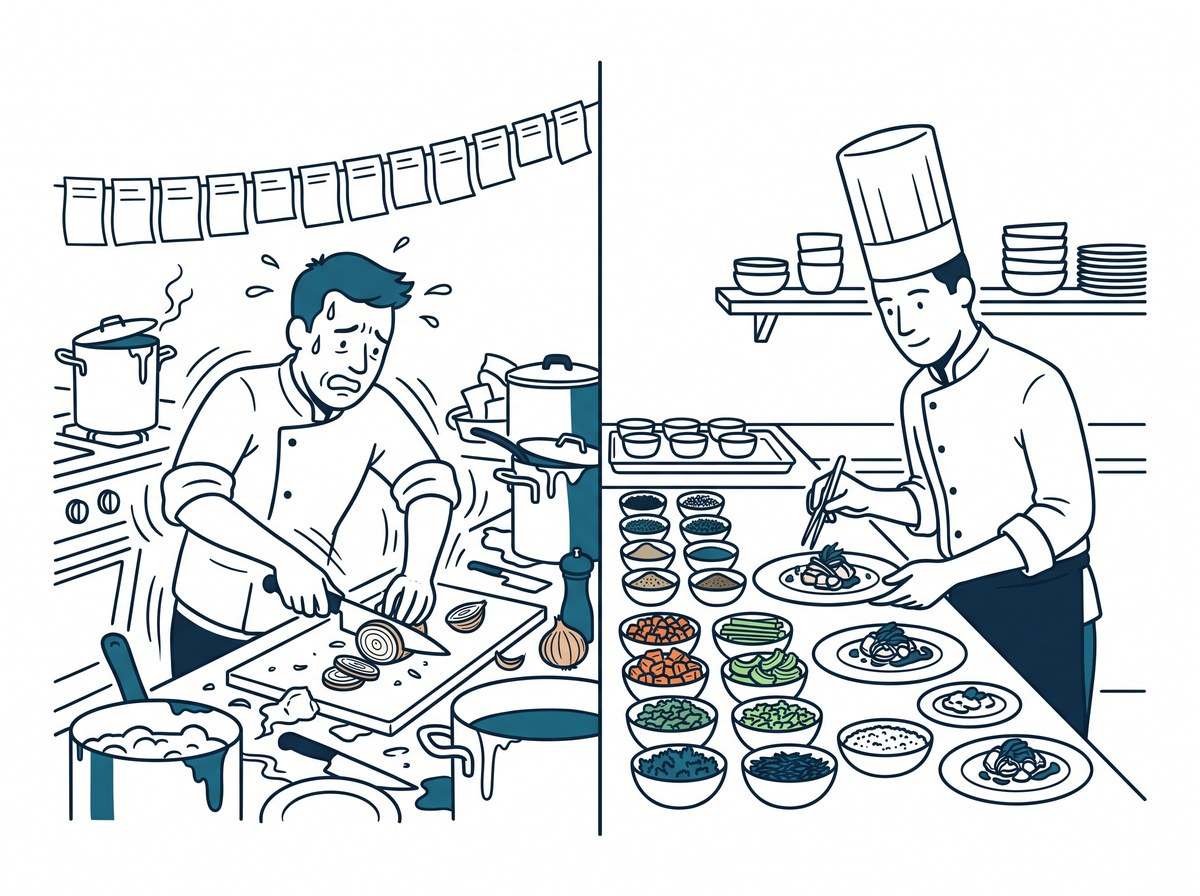<div style="text-align:center; color:#475569; font-size:0.92em; line-height:1.4; margin:-4px auto 14px; max-width:70%;">Was für jede Bestellung gleich ist, bereitet die Küche einmal vor und kocht nicht jede einzelne Bestellung „from scratch“. Genauso normalisiert <code>Corpus</code> die Absatzvektoren einmal und verwendet sie bei jeder Anfrage wieder.</div></div>

**Sondermethoden.** Für eine Liste funktionieren `len(xs)` und `xs[0]`. Für ein `Corpus`-Objekt funktionieren sie bisher nicht: `len(corpus)` endet mit `TypeError: object of type 'Corpus' has no len()`, und `corpus[0]` endet mit `TypeError: 'Corpus' object is not subscriptable`. Python sucht für diese Schreibweisen im Objekt nach Methoden mit festgelegten Namen. Die Namen beginnen und enden mit zwei Unterstrichen.

| Schreibweise | Python ruft auf | Ergebnis |
|---|---|---|
| `len(corpus)` | `corpus.__len__()` | die Anzahl der Elemente |
| `corpus[0]` | `corpus.__getitem__(0)` | das Element an dieser Position |
| `repr(corpus)` | `corpus.__repr__()` | die Darstellung als Text, die auch das Notebook für ein Objekt anzeigt |

In C++ heißt dieses Prinzip Operatorüberladung.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">10 min</span>✏️ Aufgabe 2.4 #1</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Die Zelle darunter enthält die Klasse noch einmal, ergänzt um <code>__repr__</code>. Schreiben Sie <code>__len__</code> (Anzahl der Absätze) und <code>__getitem__</code> (der Absatz an der Position <code>i</code> in <code>self.passages</code>, also das Dict mit <code>id</code>, <code>title</code> und <code>text</code>). Die Position ist unabhängig vom Feld <code>id</code> des Absatzes. Führen Sie die Zelle danach vollständig aus: Die letzte Zeile legt <code>corpus</code> neu an. Ein Objekt, das vor der Änderung angelegt wurde, gehört noch zur alten Fassung der Klasse und kennt die neuen Methoden nicht.</p>
<p>Wer früher fertig ist: Probieren Sie in einer neuen Zelle <code>corpus[-1]</code> aus. Erklären Sie, warum der negative Index funktioniert, obwohl Ihre Methode ihn nicht eigens behandelt.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> Beide Methoden sind Einzeiler, die an <code>self.passages</code> weiterreichen, was sie gefragt werden.</p></div></details>
</div>
</div>

In [ ]:
class Corpus:
    def __init__(self, passages, vectors):
        self.passages = passages
        self.vectors = []
        for v in vectors:
            self.vectors.append(normalize(v))    # einmal normalisieren und aufbewahren

    def scores(self, query_vector):
        q = normalize(query_vector)
        hits = []
        for i in range(len(self.passages)):
            hits.append((self.passages[i]["title"], dot(q, self.vectors[i])))
        return hits

    def search(self, query_vector, k=3):
        return top_hits(self.scores(query_vector), k)

    def __repr__(self):
        return f"Corpus({len(self.passages)} Absätze, {len(self.vectors[0])} Dimensionen)"

    def __len__(self):
        # TODO: Ihre Lösung hier
        ...

    def __getitem__(self, i):
        # TODO: Ihre Lösung hier
        ...

corpus = Corpus(passages, vectors)     # neu anlegen, damit das Objekt zur neuen Fassung der Klasse gehört

In [ ]:
# Prüfzelle — einfach ausführen (legt ihr eigenes Objekt an)
_c = Corpus(passages, vectors)
assert len(_c) == 400, "__len__ liefert die Anzahl der Absätze"
assert len(Corpus(passages[:3], vectors[:3])) == 3, "die Anzahl darf nicht fest eingetragen sein"
assert type(_c[0]) == dict, "__getitem__ liefert den ganzen Absatz, also das Dict"
assert _c[0]["title"] == "Aufzugsanlage", "der erste Absatz"
assert _c[399] == passages[399]
assert _c.search(query_vectors[0], 1)[0][0] == "San Diego", "die Suche funktioniert weiterhin"
# ein zweites Objekt mit eigenen Daten: Die Methoden müssen mit den Daten des Objekts arbeiten
_probe = Corpus([{"id": 999, "title": "Testabsatz", "text": "Test"}], [[3.0, 4.0]])
assert len(_probe) == 1, "__len__ muss die Absätze des Objekts zählen (self.passages)"
assert _probe[0]["title"] == "Testabsatz", "__getitem__ muss auf self.passages zugreifen, nicht auf passages"
print("Alle Prüfungen bestanden ✓")

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Anschlusslösung zur Klasse Corpus</summary><div style="color:#475569; margin:6px 0 4px;">Wenn Ihre eigene Lösung nach der Besprechung noch nicht läuft: Kopieren Sie diese Fassung in Ihre Aufgabenzelle und führen Sie die Zelle aus.</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.9em; line-height:1.4; overflow-x:auto;">class Corpus:&#10;    def __init__(self, passages, vectors):&#10;        self.passages = passages&#10;        self.vectors = []&#10;        for v in vectors:&#10;            self.vectors.append(normalize(v))&#10;&#10;    def scores(self, query_vector):&#10;        q = normalize(query_vector)&#10;        hits = []&#10;        for i in range(len(self.passages)):&#10;            hits.append((self.passages[i][&quot;title&quot;], dot(q, self.vectors[i])))&#10;        return hits&#10;&#10;    def search(self, query_vector, k=3):&#10;        return top_hits(self.scores(query_vector), k)&#10;&#10;    def __repr__(self):&#10;        return f&quot;Corpus({len(self.passages)} Absätze, {len(self.vectors[0])} Dimensionen)&quot;&#10;&#10;    def __len__(self):&#10;        return len(self.passages)&#10;&#10;    def __getitem__(self, i):&#10;        return self.passages[i]&#10;&#10;corpus = Corpus(passages, vectors)</pre></details>

Mit den drei Sondermethoden verhält sich das Objekt an diesen Stellen wie eine Liste.

In [ ]:
print(repr(corpus))
print(len(corpus))
print(corpus[0]["title"])

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#107C72; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right"><span style="border:1px solid rgba(255,255,255,0.85); color:#fff; font-size:0.72em; font-weight:bold; padding:1px 9px; border-radius:10px; margin-left:8px; vertical-align:1px;">NICHT PRÜFUNGSRELEVANT</span></span>Vertiefung: Warum auch die for-Schleife funktioniert</div>
<div style="background:#E7F4F2; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Mit <code>__getitem__</code> lässt sich das Objekt ohne weiteres Zutun durchlaufen: <code>for p in corpus:</code> funktioniert. Python fragt dafür der Reihe nach <code>corpus[0]</code>, <code>corpus[1]</code>, <code>corpus[2]</code> und so weiter ab und beendet die Schleife, sobald ein Zugriff mit einem <code>IndexError</code> scheitert. Diesen Fehler löst hier die Liste <code>self.passages</code> aus, an die <code>__getitem__</code> weiterreicht. Eine <code>__getitem__</code>-Methode, die bei zu großen Nummern keinen <code>IndexError</code> auslöst, würde die Schleife nie beenden. Der übliche Weg, ein Objekt durchlaufbar zu machen, ist die Sondermethode <code>__iter__</code>.</p>

</div>
</div>

Die Schnittstelle aus `__len__` und `__getitem__` begegnet Ihnen später im Semester wieder. Wir verwenden sie dann für PyTorch-Datensätze, auf die über eine Nummer zugegriffen wird: `__getitem__` liefert ein Beispiel, `__len__` die Anzahl der Beispiele.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">5 min</span>✏️ Aufgabe 2.4 #2</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Die Klasse <code>Corpus</code> arbeitet mit beliebigen Daten, nicht nur mit den 400 Absätzen. Die Vorgabe-Zelle darunter stellt drei neue Absätze mit zweidimensionalen Vektoren und einen Anfragevektor bereit. Lesen Sie die Vektoren als Pfeile in der Ebene: Der erste Eintrag zeigt nach Osten, der zweite nach Norden.</p>
<ol>
<li>Sagen Sie vorher, welcher Absatz bei der Suche auf Platz 1 liegt, und notieren Sie Ihre Vorhersage als Kommentar.</li>
<li>Legen Sie mit den neuen Daten ein Objekt <code>mini</code> an und speichern Sie den Titel des besten Treffers in <code>best_title</code>.</li>
<li>Schreiben Sie einen eigenen Test mit <code>assert</code>, der fehlschlägt, wenn das Normalisieren der Absatzvektoren fehlt. Begründen Sie in einem Satz als Kommentar, warum Ihr Test diesen Fehler aufdeckt.</li>
</ol>
<p>Wer früher fertig ist: Berechnen Sie in einer neuen Zelle für jeden der drei Absätze das rohe Skalarprodukt mit dem Anfragevektor, also <code>dot(mini_query, v)</code>. Welcher Absatz läge ohne Normalisieren auf Platz 1?</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> Das Objekt entsteht wie <code>corpus</code>, nur mit den neuen Listen. <code>search</code> liefert eine Liste von Paaren <code>(title, score)</code>, der Titel des besten Treffers steht also an der Stelle <code>[0][0]</code>. Für den Test: Das rohe Skalarprodukt belohnt lange Vektoren.</p></div></details>
</div>
</div>

In [ ]:
# Vorgabe: drei neue Absätze, ihre Vektoren und ein Anfragevektor — einfach ausführen
mini_passages = [{"id": 0, "title": "Nord", "text": "Absatz Nord"},
                 {"id": 1, "title": "Ost", "text": "Absatz Ost"},
                 {"id": 2, "title": "Nordost", "text": "Absatz Nordost"}]
mini_vectors = [[0.0, 2.0], [9.0, 1.0], [1.0, 1.0]]      # je Absatz ein Vektor: [nach Osten, nach Norden]
mini_query = [2.0, 3.0]                                  # der Anfragevektor

In [ ]:
# 1. Vorhersage: Welcher Absatz liegt auf Platz 1?
# TODO: Ihre Lösung hier
...

# 2. Objekt anlegen, Titel des besten Treffers in best_title speichern
# TODO: Ihre Lösung hier
...

# 3. eigener Test mit assert, darunter die Begründung als Kommentar
# TODO: Ihre Lösung hier
...

In [ ]:
# Prüfzelle — einfach ausführen
assert type(mini).__name__ == "Corpus", "mini ist ein Objekt der Klasse Corpus"
assert len(mini) == 3, "mini enthält die drei neuen Absätze"
assert mini[2]["title"] == "Nordost", "mini arbeitet mit mini_passages"
assert best_title == mini.search(mini_query, 1)[0][0], "best_title ist der Titel des besten Treffers"
for _title, _score in mini.scores(mini_query):
    assert -1.0 - 1e-9 <= _score <= 1.0 + 1e-9, "Kosinus-Werte liegen zwischen -1 und 1: Fehlt das Normalisieren?"
assert len(corpus) == 400, "corpus bleibt das Objekt mit den 400 Absätzen"
print("Alle Prüfungen bestanden ✓")

<div style="border:2px solid #7E3FA0; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; ">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#7E3FA0; font-weight:bold; font-size:1.08em;">Lernfragen 2.4 #2</span></div>
<p style="padding-left:1.2em; text-indent:-1.2em;"><b style="color:#7E3FA0;">1.</b> Die Klasse <code>Corpus</code> bewahrt die normalisierten Absatzvektoren auf. Was muss neu berechnet werden, wenn nur die Anfrage wechselt? Was muss neu berechnet werden, wenn sich ein Absatzvektor ändert?</p>

</div>

## <a id="kap-was-kostet-python"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:3px solid #156082; padding-bottom:4px;  padding-top:26px;"><span style="float:right"><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #B8860B; color:#B8860B; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M2 · Data-Science-Werkzeugkasten</span></span>2.5&nbsp;&nbsp;Was kostet Python?</span>

### <a id="kap-erst-schaetzen-dann-messen"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:1px solid rgba(21,96,130,0.45); padding-bottom:2px;  padding-top:16px;">2.5.1&nbsp;&nbsp;Erst schätzen, dann messen</span>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E75B6; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Erst schätzen, dann messen</div>
<div style="background:#EAF2FA; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Die Suche steht jetzt zweimal zur Verfügung: in reinem Python und als NumPy-Fassung aus der letzten Lerneinheit. Um welchen Faktor, schätzen Sie, ist NumPy bei einer Anfrage über 400 Absätze schneller: 5, 50 oder 500? Legen Sie sich fest, bevor Sie die nächste Zelle ausführen.</p>

</div>
</div>

Damit der Vergleich fair ist, erledigen beide Funktionen dieselbe Arbeit: Sie normalisieren die Anfrage und alle 400 Absatzvektoren und berechnen die 400 Ähnlichkeitswerte. Ausgaben und das Laden der Daten bleiben außerhalb der Messung. Ein Unterschied bleibt und gehört dazugesagt: Die Python-Fassung rechnet mit Python-Zahlen (64 Bit), NumPy mit den gespeicherten 32-Bit-Zahlen. Die NumPy-Zeilen müssen Sie heute nicht im Detail verstehen, sie sind das Thema der nächsten Lerneinheit.

In [ ]:
# Vorgabe: beide Fassungen berechnen die 400 Ähnlichkeitswerte zu einer Anfrage
def scores_python(query_no):
    q = normalize(query_vectors[query_no])
    result = []
    for v in vectors:
        result.append(dot(q, normalize(v)))
    return result

E = np.load("data/appetizer_embeddings.npy")              # die Absatzvektoren als NumPy-Array
Q = np.load("data/appetizer_query_embeddings.npy")        # die Anfragevektoren als NumPy-Array

def scores_numpy(query_no):
    q = Q[query_no] / np.linalg.norm(Q[query_no])
    return (E / np.linalg.norm(E, axis=1, keepdims=True)) @ q

t_python = measure(scores_python, 0)
t_numpy = measure(scores_numpy, 0, repeats=20)
print(f"reines Python: {t_python * 1000:7.2f} ms")
print(f"NumPy:         {t_numpy * 1000:7.2f} ms")
print(f"Faktor:        {t_python / t_numpy:7.0f}")

Die Zahlen im Skript sind auf einem Referenzrechner gemessen, Ihre Werte weichen ab. Die Größenordnung bleibt. Die Mathematik ist in beiden Fassungen dieselbe. Woher kommt der Unterschied? Das untersuchen wir im nächsten Abschnitt.

### <a id="kap-das-laufzeitmikroskop"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:1px solid rgba(21,96,130,0.45); padding-bottom:2px;  padding-top:16px;">2.5.2&nbsp;&nbsp;Das Laufzeitmikroskop</span>

Wir sehen uns an, was im Speicher liegt. Alle Angaben in diesem Abschnitt gelten für CPython, die übliche Python-Implementierung, auf einem 64-Bit-System. So laufen Colab und die Kursumgebung. In C++ belegt auf diesen Plattformen ein `double` 8 Bytes und ein `float` 4 Bytes, und ein Array legt die Werte direkt hintereinander ab. In Python ist jede Zahl ein eigenes Objekt. `sys.getsizeof` zeigt, wie viel Speicher ein Objekt belegt. Als Beispiel dient der Vektor des ersten Absatzes aus den Kursdaten, eine Liste mit 384 Zahlen.

In [ ]:
x = 1.0
print(sys.getsizeof(x), "Bytes belegt eine einzelne Python-Fließkommazahl")
v = vectors[0]                       # der Vektor des ersten Absatzes: eine Liste mit 384 Zahlen
print(sys.getsizeof(v), "Bytes belegt diese Liste, ohne die Zahlen darin")

Das Objekt einer Fließkommazahl enthält die 8 Bytes des eigentlichen Zahlenwerts und dazu 16 Bytes Verwaltungsdaten: den Typ und einen Zähler, der festhält, wie viele Namen und Container auf das Objekt verweisen. Die Liste selbst speichert keine Zahlen. Sie enthält je Element einen Verweis von 8 Bytes auf ein Zahlenobjekt, das irgendwo im Speicher liegt.

Eine Zeile wie `total += x * x` kostet in der Python-Schleife bei jedem Durchlauf mehr als die beiden Rechenoperationen. In C++ stehen die Typen beim Übersetzen fest, der Compiler legt die passenden Maschinenbefehle einmal vorab fest. Multipliziert und addiert wird auch dort in jedem Durchlauf. Es entfallen aber die Typprüfungen und die Verwaltung von Python-Zahlenobjekten.

<details style="margin-top:10px"><summary style="cursor:pointer; color:#1F5FB0; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #1F5FB055"><p>In Python sieht ein Durchlauf vereinfacht so aus: Der Interpreter folgt dem Verweis aus der Liste zum Zahlenobjekt. Er prüft den Typ des Objekts, denn eine Liste kann Objekte beliebiger Typen enthalten. Er wählt die Multiplikation aus, die zu diesem Typ gehört, und führt sie aus. Für das Ergebnis legt er ein neues Zahlenobjekt an. Dasselbe wiederholt sich für die Addition. Die eigentliche Rechnung ist der kleinste Teil dieser Arbeit. Diese Beschreibung ist vereinfacht. Aktuelle CPython-Versionen merken sich bei häufig ausgeführten Stellen die passende Operation und sparen einen Teil der Auswahl. Die Objekte und die Verweise bleiben.</p></div></details>

<div style="break-inside:avoid; page-break-inside:avoid;">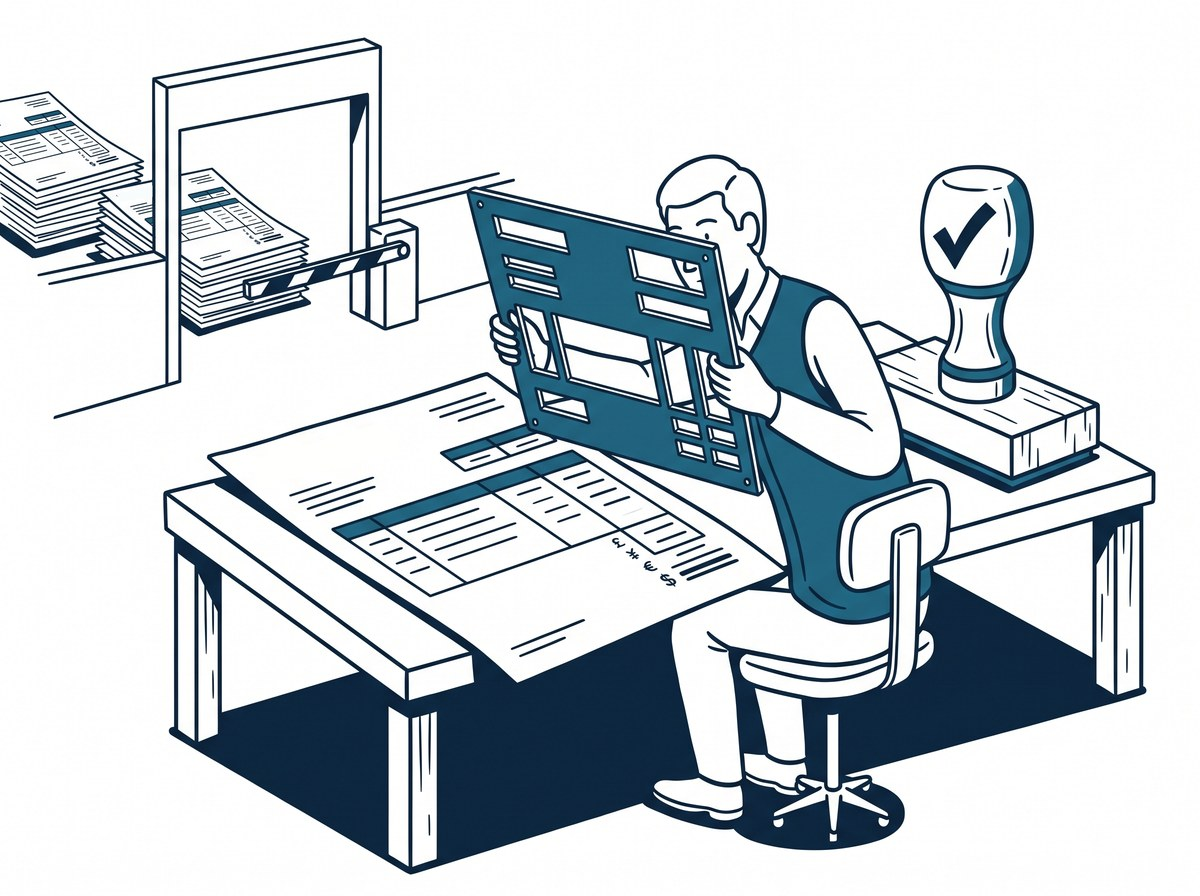<div style="text-align:center; color:#475569; font-size:0.92em; line-height:1.4; margin:-4px auto 14px; max-width:70%;">Wie ein Prüfer, der jedes Formular erst an die Schablone hält, erledigt der Interpreter vor jeder einzelnen Rechnung die Formalitäten: Verweis verfolgen, Typ prüfen, Operation auswählen. Die Rechnung selbst ist der kleinste Teil der Arbeit.</div></div>

**Hilft kompakter Speicher?** Die Standardbibliothek bringt mit `array.array` einen Container mit, der Zahlen so ablegt wie ein C-Array: gleichartig und direkt hintereinander, hier mit 4 Bytes je Zahl.

In [ ]:
import array

a = array.array("f", vectors[0])       # der Vektor des ersten Absatzes, dicht gepackt
print(a.itemsize, "Bytes je Zahl,", a.itemsize * len(a), "Bytes für alle 384 Zahlen")

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000; font-weight: bold">import</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">array</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; <code>array.array(&quot;f&quot;, ...)</code> legt die Zahlen dicht gepackt ab, das <code>&quot;f&quot;</code> steht für Fließkommazahlen mit 32 Bit</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>a <span style="color: #666">=</span> array<span style="color: #666">.</span>array(<span style="color: #BA2121">"f"</span>, vectors[<span style="color: #666">0</span>])       <span style="color: #3D7B7B; font-style: italic"># der Vektor des ersten Absatzes, dicht gepackt</span></code></pre><div style="margin:8px 0 2px; color:#475569;"><b>②</b>&nbsp; <code>itemsize</code> ist der Speicherbedarf je Zahl in Bytes</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(a<span style="color: #666">.</span>itemsize, <span style="color: #BA2121">"Bytes je Zahl,"</span>, a<span style="color: #666">.</span>itemsize <span style="color: #666">*</span> <span style="color: #008000">len</span>(a), <span style="color: #BA2121">"Bytes für alle 384 Zahlen"</span>)</code></pre></details>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E75B6; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Erst schätzen, dann messen</div>
<div style="background:#EAF2FA; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Die nächste Zelle berechnet die geometrische Länge eines Vektors mit einer Million Einträgen dreimal: über eine Python-Liste, über ein <code>array.array</code> und mit NumPy. Die ersten beiden nutzen Ihre Funktion <code>norm</code>. Ist die Schleife über das kompakte <code>array.array</code> schneller als die über die Liste?</p>

</div>
</div>

In [ ]:
big_list = []
for i in range(1_000_000):
    big_list.append(i * 0.5)                       # eine Million Zahlen als Liste
big_array = array.array("f", big_list)             # dieselben Zahlen dicht gepackt
big_numpy = np.array(big_list, dtype=np.float32)   # dieselben Zahlen als NumPy-Array

t_loop_list = measure(norm, big_list)
t_loop_array = measure(norm, big_array)
t_loop_numpy = measure(np.linalg.norm, big_numpy)
print(f"Schleife über die Liste:      {t_loop_list * 1000:7.2f} ms")
print(f"Schleife über das array:      {t_loop_array * 1000:7.2f} ms")
print(f"NumPy:                        {t_loop_numpy * 1000:7.2f} ms")

Die Schleife über das `array.array` ist nicht schneller, meist sogar etwas langsamer. Der Grund: Die Schleife läuft weiter im Interpreter und rechnet mit Zahlenobjekten. Bei jedem Zugriff muss Python aus den rohen 4 Bytes erst ein solches Objekt bauen. Die Liste hat die fertigen Objekte schon.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E75B6; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Kompakter Speicher allein genügt nicht</div>
<div style="background:#EAF2FA; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Schnell wird die Rechnung erst, wenn beides zusammenkommt: Die Zahlen liegen als zusammenhängender Block im Speicher, und die Schleife über diesen Block läuft in Maschinencode statt im Interpreter. Genau das leistet NumPy, und damit beginnt die nächste Lerneinheit.</p>

</div>
</div>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">5 min</span>✏️ Aufgabe 2.5.2 #1</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Schätzen Sie den Speicherbedarf der Kursvektoren, 400 Vektoren mit je 384 Zahlen. Berechnen Sie <code>bytes_lists</code> für die Ablage als Python-Listen: je Zahl ein Objekt und ein Verweis. Berechnen Sie <code>bytes_block</code> für die Ablage als Block mit 4 Bytes je Zahl. Die Größen aus diesem Abschnitt genügen dafür.</p>
<p>Wer früher fertig ist: Die Rechnung berücksichtigt nur die Zahlenobjekte und die Verweise auf sie. Die 401 Listen belegen zusätzlich je 56 Bytes für ihre eigene Verwaltung, und die äußere Liste hält 400 Verweise auf die inneren Listen. Rechnen Sie aus, wie viele Bytes dadurch hinzukommen.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> Rechnen Sie mit den Größen unserer Umgebung: Ein Zahlenobjekt belegt 24 Bytes, ein Verweis in der Liste 8 Bytes.</p></div></details>
</div>
</div>

In [ ]:
n = 400 * 384                      # Anzahl der Zahlen in den Kursvektoren
# TODO: Ihre Lösung hier
...

In [ ]:
# Prüfzelle — einfach ausführen
assert bytes_lists == 4_915_200, "je Zahl 24 Bytes für das Objekt und 8 Bytes für den Verweis"
assert bytes_block == 614_400, "je Zahl 4 Bytes"
print(f"als Listen: {bytes_lists / 1e6:.2f} MB   als Block: {bytes_block / 1e6:.2f} MB   Faktor {bytes_lists / bytes_block:.0f}")
print("Alle Prüfungen bestanden ✓")

Zum Nachmessen muss `sys.getsizeof` auf jeder Ebene einzeln aufgerufen werden: Für die äußere Liste liefert die Funktion nur deren eigene Größe, weder die inneren Listen noch die Zahlenobjekte zählen mit.

In [ ]:
measured = sys.getsizeof(vectors)              # die äußere Liste
for v in vectors:
    measured += sys.getsizeof(v)               # jede innere Liste
    for x in v:
        measured += sys.getsizeof(x)           # jedes Zahlenobjekt
print(f"gemessen: {measured / 1e6:.2f} MB")

### <a id="kap-was-kostet-ein-container"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:1px solid rgba(21,96,130,0.45); padding-bottom:2px;  padding-top:16px;">2.5.3&nbsp;&nbsp;Was kostet ein Container?</span>

Auch die Wahl des Containers kostet oder spart Zeit. Ein häufiger Fall ist die Frage, ob ein Wert in einem Container vorkommt. Schätzen Sie zuerst: Eine Liste und ein Set enthalten dieselbe Million Zahlen. Gesucht wird ein Wert, der nicht vorkommt. Um welchen Faktor unterscheiden sich die Suchzeiten?

Einzelne Suchen im Set sind zu kurz für eine verlässliche Messung. Die Zelle misst deshalb viele Suchen am Stück und teilt die Zeit durch deren Anzahl. Beide Container sind vor der Messung fertig aufgebaut.

In [ ]:
def search_many(container, value, repeats):
    for _ in range(repeats):
        value in container                  # das Ergebnis wird nicht gebraucht, es geht um die Zeit

print(f"{'Elemente':>10s}{'Liste':>14s}{'Set':>12s}")
for n in [1_000, 10_000, 100_000, 1_000_000]:
    xs = list(range(n))                     # Liste mit den Zahlen 0 bis n-1
    s = set(xs)                             # dieselben Zahlen als Set
    t_list = measure(search_many, xs, -1, 10) / 10               # Zeit je Suche in der Liste
    t_set = measure(search_many, s, -1, 100_000) / 100_000       # Zeit je Suche im Set
    print(f"{n:>10,}{t_list * 1e6:>11.1f} µs{t_set * 1e6:>9.2f} µs")

Die Liste wird Element für Element durchsucht. Fehlt der Wert, muss Python alle Elemente ansehen, und die Zeit wächst mit der Länge der Liste. Das Set berechnet aus dem gesuchten Wert eine Kennzahl, den Hashwert, und sieht nur an der Stelle nach, die zu dieser Kennzahl gehört. Die Suchzeit hängt dadurch im Mittel kaum von der Größe des Sets ab.

<details style="margin-top:10px"><summary style="cursor:pointer; color:#1F5FB0; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #1F5FB055"><p>„Im Mittel" ist dabei wörtlich gemeint. Verschiedene Werte können auf dieselbe Stelle fallen, dann sind einige zusätzliche Vergleiche nötig. Python hält die Tabelle so groß, dass das selten vorkommt. Ein Dict arbeitet mit seinen Schlüsseln auf dieselbe Weise, deshalb ist auch der Zugriff <code>d[key]</code> unabhängig von der Größe des Dicts schnell. Der Preis ist Speicher: Set und Dict belegen mehr Platz als eine Liste mit denselben Elementen.</p></div></details>

<div style="break-inside:avoid; page-break-inside:avoid;">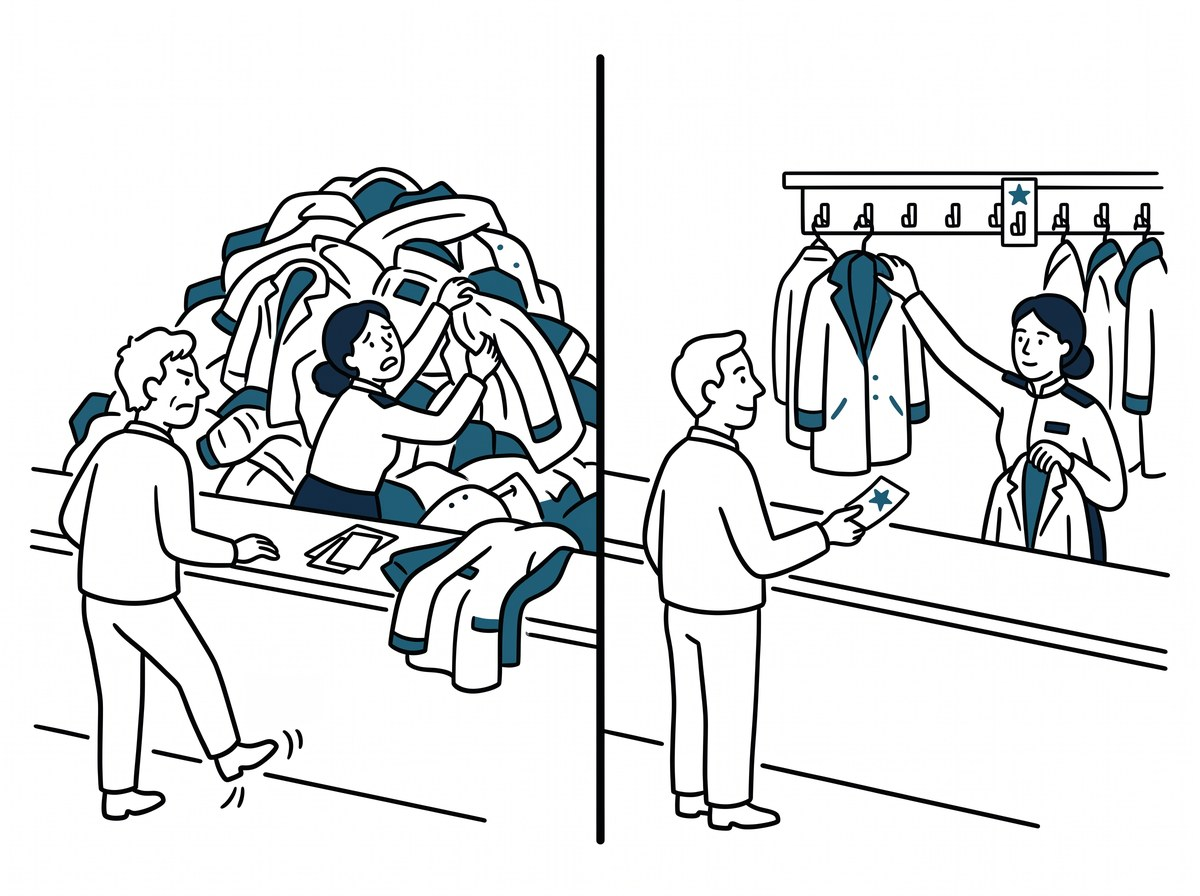<div style="text-align:center; color:#475569; font-size:0.92em; line-height:1.4; margin:-4px auto 14px; max-width:70%;">Mit der Marke führt der Weg direkt zum richtigen Haken, so wie der Hashwert im Set direkt zur richtigen Stelle führt. Ohne Marke bleibt nur, alle Mäntel der Reihe nach durchzusehen, wie in der Liste.</div></div>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#107C72; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right"><span style="border:1px solid rgba(255,255,255,0.85); color:#fff; font-size:0.72em; font-weight:bold; padding:1px 9px; border-radius:10px; margin-left:8px; vertical-align:1px;">NICHT PRÜFUNGSRELEVANT</span></span>Vertiefung: Wie sind Set und Dict gespeichert?</div>
<div style="background:#E7F4F2; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Beide nutzen intern eine Hashtabelle. Das ist ein Feld mit festen Plätzen, und der Hashwert bestimmt, an welchem Platz ein Element liegt. Ein Teil der Plätze bleibt frei. Deshalb belegen Set und Dict ein Mehrfaches einer Liste mit denselben Elementen.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#107C72; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #107C7255"><p>Jeder belegte Platz hält den Hashwert und einen Verweis auf das Objekt. Beim Dict kommt je Eintrag ein Verweis auf den Wert hinzu. Damit selten zwei Werte auf denselben Platz fallen, hält CPython einen Teil der Plätze frei und legt eine größere Tabelle an, sobald die alte zu voll wird. Die freien Plätze und die gespeicherten Hashwerte kosten Speicher. Das folgende Beispiel misst das für 100.000 Zahlen, jeweils nur den Container ohne die Zahlenobjekte. Die Werte können sich zwischen Python-Versionen leicht unterscheiden.</p>
<pre><code class="language-python">xs = list(range(100_000))        # 100.000 Zahlen als Liste
s = set(xs)                      # dieselben Zahlen als Set
d = dict.fromkeys(xs)            # ein Dict, das jede Zahl aus xs als Schlüssel enthält
for name, container in [(&quot;Liste&quot;, xs), (&quot;Set&quot;, s), (&quot;Dict&quot;, d)]:
    print(f&quot;{name}: {sys.getsizeof(container) / 1e6:.1f} MB&quot;)
# Ausgabe: Liste: 0.8 MB, Set: 4.2 MB, Dict: 5.2 MB
</code></pre></div></details>
</div>
</div>

<div style="border:2px solid #475569; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#475569; font-weight:bold; font-size:1.08em;">Welcher Container für welche Aufgabe?</span></div>
<p>Die Wahl richtet sich nach der Operation, die am häufigsten vorkommt.</p>
<table>
<thead>
<tr>
<th>Häufigste Operation</th>
<th>Passender Container</th>
<th>Schreibweise</th>
<th>Zeit für diese Operation</th>
</tr>
</thead>
<tbody>
<tr>
<td>Zugriff über die Position</td>
<td>Liste</td>
<td><code>xs[i]</code></td>
<td>unabhängig von der Länge der Liste</td>
</tr>
<tr>
<td>Zugriff auf einen Wert eines festen Pakets</td>
<td>Tupel</td>
<td><code>hit[0]</code></td>
<td>unabhängig von der Länge des Tupels</td>
</tr>
<tr>
<td>Nachschlagen über einen Schlüssel</td>
<td>Dict</td>
<td><code>d[key]</code></td>
<td>im Mittel unabhängig von der Größe des Dicts</td>
</tr>
<tr>
<td>Prüfen, ob ein Wert vorkommt</td>
<td>Set</td>
<td><code>x in s</code></td>
<td>im Mittel unabhängig von der Größe des Sets</td>
</tr>
</tbody>
</table>
<p>Zum Vergleich: Die Prüfung <code>x in xs</code> in einer Liste braucht eine Zeit, die mit der Länge der Liste wächst. Auch das Auspacken eines Tupels, etwa <code>title, score = hit</code>, weist jeden Wert einzeln zu. Die Arbeit wächst dort mit der Anzahl der Werte.</p>

</div>

**Brauchen wir diese Container noch, wenn später NumPy und PyTorch rechnen?** Ja, für andere Aufgaben. Die Zahlenblöcke, mit denen gerechnet wird, liegen später in Arrays und Tensoren. Was das Programm darum herum organisiert, bleibt in den Containern von Python. Beispiele sind die Einstellungen eines Trainingslaufs als Dict, die Liste der Dateien eines Datensatzes und das Vokabular eines Tokenizers als Dict, das jedem Token eine Nummer zuordnet. Auch PyTorch selbst liefert die Gewichte eines Modells als Dict, das jedem Namen einen Tensor zuordnet.

Für die nächste Aufgabe stellt die Vorgabe-Zelle alle Wörter des Korpus als eine lange Liste bereit. Die Texte werden dafür in Kleinbuchstaben umgewandelt und an Leerzeichen und Zeilenumbrüchen getrennt. Satzzeichen bleiben am Wort hängen, „stadt" und „stadt." gelten also als verschiedene Wörter.

In [ ]:
# Vorgabe: alle Wörter des Korpus als Liste — einfach ausführen
words = []
for p in passages:
    for w in p["text"].lower().split():
        words.append(w)
print(len(words), "Wörter")

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #3D7B7B; font-style: italic"># Vorgabe: alle Wörter des Korpus als Liste — einfach ausführen</span>
words <span style="color: #666">=</span> []
<span style="color: #008000; font-weight: bold">for</span> p <span style="color: #A2F; font-weight: bold">in</span> passages:</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; <code>lower()</code> wandelt einen Text in Kleinbuchstaben um, <code>split()</code> trennt ihn an Leerraum in eine Liste von Wörtern</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code>    <span style="color: #008000; font-weight: bold">for</span> w <span style="color: #A2F; font-weight: bold">in</span> p[<span style="color: #BA2121">"text"</span>]<span style="color: #666">.</span>lower()<span style="color: #666">.</span>split():
        words<span style="color: #666">.</span>append(w)
<span style="color: #008000">print</span>(<span style="color: #008000">len</span>(words), <span style="color: #BA2121">"Wörter"</span>)</code></pre></details>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">5 min</span>✏️ Aufgabe 2.5.3 #1</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Bilden Sie aus <code>words</code> ein Set <code>word_set</code>. Messen Sie dann mit <code>measure</code> und <code>search_many</code>, wie lange die Suche nach dem Wort <code>"quantencomputer"</code> dauert, das im Korpus nicht vorkommt: in <code>t_in_list</code> die Zeit je Suche in der Liste, in <code>t_in_set</code> die Zeit je Suche im Set. Orientieren Sie sich an der Messzelle oben.</p>
<p>Wer früher fertig ist: Wie viele verschiedene Wörter enthält der Korpus, und wie viele wären es ohne die Umwandlung in Kleinbuchstaben? Schätzen Sie erst, ob die Zahl steigt oder fällt. Bauen Sie dann die Wortliste in einer neuen Zelle ohne <code>lower()</code> auf und zählen Sie nach.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> <code>measure(search_many, words, "quantencomputer", 10) / 10</code> misst zehn Suchen in der Liste und teilt durch zehn. Für das Set nehmen Sie 100.000 Wiederholungen.</p></div></details>
</div>
</div>

In [ ]:
# TODO: Ihre Lösung hier
...

In [ ]:
# Prüfzelle — einfach ausführen
assert type(word_set) == set, "word_set soll ein Set sein"
assert len(word_set) == 19798, "das Set enthält jedes Wort genau einmal"
assert "quantencomputer" not in word_set
assert t_in_set < t_in_list, "die Suche im Set sollte deutlich schneller sein"
print(f"Liste: {t_in_list * 1e6:.1f} µs je Suche   Set: {t_in_set * 1e6:.3f} µs je Suche   Faktor {t_in_list / t_in_set:,.0f}")
print("Alle Prüfungen bestanden ✓")

<div style="border:2px solid #7E3FA0; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; ">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#7E3FA0; font-weight:bold; font-size:1.08em;">Lernfragen 2.5.3 #1</span></div>
<p style="padding-left:1.2em; text-indent:-1.2em;"><b style="color:#7E3FA0;">1.</b> Lohnt es sich, das Set aufzubauen, wenn nur ein einziges Wort gesucht werden soll? Überlegen Sie, was der Aufbau kostet, und messen Sie ihn in der Zelle darunter.</p>

</div>

In [ ]:
t_build_set = measure(set, words)
t_one_search = measure(search_many, words, "quantencomputer", 1)
print(f"Set aufbauen: {t_build_set * 1000:.2f} ms   eine Suche in der Liste: {t_one_search * 1000:.2f} ms")

## <a id="kap-zahlen-im-rechner"></a><span class="zwischentitel" style="display:block; color:#0E2841; border-bottom:3px solid #156082; padding-bottom:4px;  padding-top:26px;"><span style="float:right"><span class="modulchip" style="font-size:0.55em; font-weight:bold; letter-spacing:0.02em; border:1.5px solid #B8860B; color:#B8860B; padding:1px 8px; border-radius:10px; margin-left:12px; vertical-align:0.35em; white-space:nowrap;">M2 · Data-Science-Werkzeugkasten</span></span>2.6&nbsp;&nbsp;Zahlen im Rechner</span>

<div style="border:2px solid #E97132; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#E97132; font-weight:bold; font-size:1.08em;">💭 Kurz überlegen</span></div>
<p>Was liefert <code>0.1 + 0.2 == 0.3</code>? Legen Sie sich fest, bevor Sie die nächste Zelle ausführen.</p>

</div>

In [ ]:
print(0.1 + 0.2)
print(0.1 + 0.2 == 0.3)

total = 0.0
for _ in range(10):
    total += 0.1                 # zehnmal 0.1 addieren
print(total)

Der Rechner speichert Fließkommazahlen binär, als Summe von Zweierpotenzen. Die meisten Dezimalbrüche lassen sich so nicht exakt darstellen. Gespeichert wird die nächstgelegene darstellbare Zahl, und jede Rechnung rundet erneut.

<details style="margin-top:10px"><summary style="cursor:pointer; color:#1F5FB0; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #1F5FB055"><p>Im Dezimalsystem kennen Sie dasselbe von 1/3: Die Ziffernfolge 0,333… bricht nie ab, jede Darstellung mit endlich vielen Stellen ist gerundet. Im Binärsystem trifft es schon 0,1. Die gespeicherte Zahl liegt minimal daneben, und bei jeder Rechnung können sich solche Abweichungen fortpflanzen. Das ist kein Fehler von Python, in C++ verhalten sich <code>double</code> und <code>float</code> genauso.</p></div></details>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#107C72; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right"><span style="border:1px solid rgba(255,255,255,0.85); color:#fff; font-size:0.72em; font-weight:bold; padding:1px 9px; border-radius:10px; margin-left:8px; vertical-align:1px;">NICHT PRÜFUNGSRELEVANT</span></span>Vertiefung: Wie ist eine Fließkommazahl gespeichert?</div>
<div style="background:#E7F4F2; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Die üblichen Formate folgen dem Standard IEEE 754 und teilen ihre Bits in drei Felder für Vorzeichen, Exponent und Mantisse. Der Wert ergibt sich als Vorzeichen mal Mantisse mal 2 hoch Exponent. Das ist die wissenschaftliche Schreibweise, die Sie von 6,02 · 10²³ kennen, nur zur Basis 2.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#107C72; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #107C7255"><p>Ein Bit hält das Vorzeichen. Der Exponent legt die Größenordnung als Zweierpotenz fest. Er wird mit einem festen Versatz gespeichert, damit auch negative Exponenten darstellbar sind: Bei <code>float32</code> wird vom gespeicherten Wert 127 abgezogen. Die Mantisse hält die Ziffern der Zahl, und ihre Länge begrenzt die Genauigkeit. Die Abbildung zeigt die 32 Bit, mit denen <code>float32</code> die Zahl 0.1 speichert.</p>
<p></p></div></details>
</div>
</div>

<div style="border:2px solid #475569; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#475569; font-weight:bold; font-size:1.08em;">Zwei Formate für Fließkommazahlen</span></div>
<p>Zwei Formate sind üblich. Sie unterscheiden sich in Speicherbedarf und Genauigkeit.</p>
<table>
<thead>
<tr>
<th>Format</th>
<th>Speicher für den Zahlenwert</th>
<th>ungefähre Genauigkeit</th>
<th>wo</th>
</tr>
</thead>
<tbody>
<tr>
<td><code>float64</code></td>
<td>8 Bytes</td>
<td>15 bis 16 signifikante Dezimalziffern</td>
<td>der Python-<code>float</code>, in C++ <code>double</code></td>
</tr>
<tr>
<td><code>float32</code></td>
<td>4 Bytes</td>
<td>6 bis 7 signifikante Dezimalziffern</td>
<td>in C++ <code>float</code>, Standard in KI-Bibliotheken</td>
</tr>
</tbody>
</table>
<p>Die Zahl der Bits begrenzt die Genauigkeit. Signifikante Ziffern sind die Ziffern einer Zahl ab der ersten Ziffer, die nicht 0 ist. Die Position des Kommas spielt dafür keine Rolle: 123456,7 und 0,001234567 haben jeweils sieben signifikante Ziffern. Durch Rechnungen kann weitere Genauigkeit verloren gehen. Die 8 Bytes sind der reine Zahlenwert. Als Python-Objekt belegt eine solche Zahl 24 Bytes, wie im Kapitel <a href="#kap-das-laufzeitmikroskop">2.5.2</a> gemessen.</p>

</div>

<div style="border:2px solid #475569; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="float:right"><span style="border:1px solid #475569; color:#475569; font-size:0.75em; font-weight:bold; padding:1px 9px; border-radius:10px; margin-left:8px; vertical-align:1px;">NICHT PRÜFUNGSRELEVANT</span></span><span style="color:#475569; font-weight:bold; font-size:1.08em;">Exkurs: Datentypen, die Dezimalbrüche exakt speichern</span></div>
<p>Es gibt Datentypen, die Dezimalbrüche exakt speichern. Sie legen die Dezimalziffern selbst ab statt einer binären Näherung. Python bringt dafür <code>decimal.Decimal</code> mit, außerdem <code>fractions.Fraction</code> für exakte Brüche. Java kennt <code>BigDecimal</code>, C# den Typ <code>decimal</code>, Datenbanken kennen <code>DECIMAL</code> und <code>NUMERIC</code>. Eingesetzt werden diese Typen vor allem für Geldbeträge.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#475569; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #47556955"><p>Der Preis: Diese Typen rechnen in Software statt mit den Fließkomma-Befehlen des Prozessors und sind deshalb langsamer. Sie belegen mehr Speicher, und Grafikprozessoren bieten für sie keine Rechenbefehle. Auch diese Typen haben Grenzen. <code>Decimal</code> speichert endliche Dezimalzahlen exakt. Der Bruch 1/3 hat keine endliche Dezimaldarstellung und wird bei <code>Decimal</code> auf die eingestellte Stellenzahl gerundet. <code>Fraction</code> speichert Zähler und Nenner und stellt deshalb auch 1/3 exakt dar. Irrationale Zahlen wie die Wurzel aus 2 kann keiner der beiden Typen exakt darstellen. Für das numerische Rechnen mit Millionen von Werten sind Fließkommazahlen deshalb üblich, und die kleinen Abweichungen werden mit Toleranzen abgefangen.</p></div></details>
</div>

In [ ]:
from decimal import Decimal
from fractions import Fraction

print(Decimal("0.1") + Decimal("0.2") == Decimal("0.3"))
print(Fraction(1, 10) + Fraction(2, 10) == Fraction(3, 10))
print(Decimal(1) / Decimal(3))                 # Decimal rundet 1/3 auf die eingestellte Stellenzahl
print(Fraction(1, 3) * 3 == 1)                 # Fraction stellt 1/3 exakt dar

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Code Schritt für Schritt</summary><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000; font-weight: bold">from</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">decimal</span><span style="color: #BBB"> </span><span style="color: #008000; font-weight: bold">import</span> Decimal
<span style="color: #008000; font-weight: bold">from</span><span style="color: #BBB"> </span><span style="color: #00F; font-weight: bold">fractions</span><span style="color: #BBB"> </span><span style="color: #008000; font-weight: bold">import</span> Fraction</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>①</b>&nbsp; <code>Decimal(&quot;0.1&quot;)</code> speichert die Dezimalziffern der Zahl exakt, angegeben wird sie als Text</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(Decimal(<span style="color: #BA2121">"0.1"</span>) <span style="color: #666">+</span> Decimal(<span style="color: #BA2121">"0.2"</span>) <span style="color: #666">==</span> Decimal(<span style="color: #BA2121">"0.3"</span>))</code></pre><div style="margin:8px 0 2px; color:#475569;"><b>②</b>&nbsp; <code>Fraction(1, 10)</code> speichert den Bruch 1/10 mit Zähler und Nenner</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.82em; line-height:1.4; overflow-x:auto; margin:2px 0 8px; text-align:left;"><code><span style="color: #008000">print</span>(Fraction(<span style="color: #666">1</span>, <span style="color: #666">10</span>) <span style="color: #666">+</span> Fraction(<span style="color: #666">2</span>, <span style="color: #666">10</span>) <span style="color: #666">==</span> Fraction(<span style="color: #666">3</span>, <span style="color: #666">10</span>))
<span style="color: #008000">print</span>(Decimal(<span style="color: #666">1</span>) <span style="color: #666">/</span> Decimal(<span style="color: #666">3</span>))                 <span style="color: #3D7B7B; font-style: italic"># Decimal rundet 1/3 auf die eingestellte Stellenzahl</span>
<span style="color: #008000">print</span>(Fraction(<span style="color: #666">1</span>, <span style="color: #666">3</span>) <span style="color: #666">*</span> <span style="color: #666">3</span> <span style="color: #666">==</span> <span style="color: #666">1</span>)                 <span style="color: #3D7B7B; font-style: italic"># Fraction stellt 1/3 exakt dar</span></code></pre></details>

Die Kursvektoren sind als `float32` gespeichert. Das halbiert den Speicherbedarf, und GPUs rechnen in diesem Format und in noch kleineren Formaten am schnellsten. Was die geringere Genauigkeit bedeutet, zeigt ein `array.array` mit 32-Bit-Zahlen. Es speichert 0.1 und liefert beim Auslesen einen sichtbar anderen Wert zurück. Das zweite Beispiel ist eine ganze Zahl. Bis einschließlich 2²⁴ = 16.777.216 stellt `float32` jede ganze Zahl exakt dar. Direkt darüber beträgt der Abstand zwischen zwei darstellbaren Zahlen 2. Die 16.777.217 liegt dazwischen und wird hier auf 16.777.216 gerundet.

In [ ]:
a = array.array("f", [0.1, 16777217.0])      # zwei Zahlen als 32-Bit-Zahlen speichern
print(a[0])                                  # 0.1 kommt sichtbar verändert zurück
print(a[1])                                  # oberhalb von 2**24 liegen darstellbare Zahlen im Abstand 2

<div style="border:2px solid #475569; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; margin-right:-20px;">
<div style="overflow:hidden; margin-bottom:4px;"><span style="float:right"><span style="border:1px solid #475569; color:#475569; font-size:0.75em; font-weight:bold; padding:1px 9px; border-radius:10px; margin-left:8px; vertical-align:1px;">NICHT PRÜFUNGSRELEVANT</span></span><span style="color:#475569; font-weight:bold; font-size:1.08em;">Exkurs: Quantisierung von Sprachmodellen</span></div>
<p>Die Gewichte eines Sprachmodells sind Fließkommazahlen, und ihr Format bestimmt den Speicherbedarf. Ein Modell mit 8 Milliarden Gewichten belegt in <code>float32</code> rund 32 GB, in einem Format mit 16 Bit rund 16 GB. Quantisierung geht weiter und speichert jedes Gewicht als kleine ganze Zahl mit 8 oder 4 Bit, zusammen mit einem Umrechnungsfaktor je Gruppe von Gewichten. Dasselbe Modell kommt dann mit rund 8 GB oder 4 GB aus.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#475569; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #47556955"><p>Der Preis ist Genauigkeit: Mit 4 Bit lassen sich nur 16 verschiedene Werte unterscheiden. Die Antworten des Modells können dadurch schlechter werden. Wie stark, hängt von Modell, Verfahren und Aufgabe ab. Quantisiert wird in der Regel ein fertig trainiertes Modell für den Betrieb. Trainiert wird meist in <code>float32</code> oder in einer Mischung aus 16 und 32 Bit. Der Speicherbedarf entscheidet darüber, ob ein Modell in den Speicher einer Grafikkarte passt. Darauf kommen wir später im Semester zurück.</p></div></details>
</div>

Jetzt lässt sich erklären, warum die Prüfzellen dieses Notebooks einen Abstand prüfen. Schon ein normalisierter Vektor hat selten exakt die Länge 1:

In [ ]:
print(norm(normalize([3.0, 4.0])))
print(norm(normalize([1.0, 1.0])))

exact = 0
for v in vectors:
    if norm(normalize(v)) == 1.0:
        exact += 1
print(exact, "von", len(vectors), "normalisierten Absatzvektoren haben exakt die Länge 1.0")

**Vergleichen mit Toleranz.** Wer Ergebnisse von Rechnungen mit Fließkommazahlen vergleicht, legt fest, welche Abweichung noch als gleich gilt. Das einfachste Muster ist der absolute Abstand: `abs(a - b) <= tol`, wobei `tol` für die Toleranz steht. Die Standardbibliothek bietet dafür `math.isclose(a, b)`. Ohne weitere Angaben prüft diese Funktion einen relativen Abstand: Die Zahlen müssen in etwa neun Stellen übereinstimmen. Beim Vergleich mit 0 hilft das nicht, dort gibt man mit `abs_tol` zusätzlich einen absoluten Abstand an. Welche Toleranz angemessen ist, hängt von der Rechnung ab. Für die kleinen Rechnungen mit 64-Bit-Zahlen in diesem Notebook genügt `1e-9`. Beim Vergleich mit den 32-Bit-Werten aus NumPy wäre das zu streng, dort stimmen nur sechs bis sieben Ziffern.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#2E7D32; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right; font-weight:600; font-size:0.85em; opacity:0.95;">5 min</span>✏️ Aufgabe 2.6 #1</div>
<div style="background:#EAF4EB; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Schreiben Sie die Funktion <code>is_unit(v, tol=1e-9)</code>. Sie prüft, ob <code>v</code> ein Einheitsvektor ist, also die Länge 1 hat. Der Parameter <code>tol</code> steht für die Toleranz: Die Funktion gibt <code>True</code> zurück, wenn die Länge von <code>v</code> höchstens um <code>tol</code> von 1 abweicht, sonst <code>False</code>. Notieren Sie darunter als Kommentar in einem Satz, warum <code>norm(v) == 1.0</code> für diesen Test ungeeignet ist.</p>
<p>Wer früher fertig ist: Finden Sie einen Vektor, für den <code>is_unit</code> mit der Standardtoleranz <code>False</code> liefert und mit <code>tol=0.01</code> den Wert <code>True</code>. Seine Länge muss dafür knapp neben 1 liegen. Prüfen Sie beide Aufrufe in einer neuen Zelle.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#2E7D32; font-weight:600; font-size:0.9em">Hinweis anzeigen</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #2E7D3255"><p><strong>Hinweis:</strong> Die Abweichung kann nach oben oder nach unten gehen. Der Betrag <code>abs(...)</code> erfasst beide Richtungen.</p></div></details>
</div>
</div>

In [ ]:
def is_unit(v, tol=1e-9):
    # TODO: Ihre Lösung hier
    ...

# Warum ist norm(v) == 1.0 als Test ungeeignet?
# TODO: Ihre Lösung hier
...

In [ ]:
# Prüfzelle — einfach ausführen
assert is_unit([1.0, 0.0]) == True, "ein Vektor der Länge 1"
assert is_unit(normalize([1.0, 1.0])) == True, "0.9999999999999999 gilt als Länge 1"
assert is_unit(normalize(vectors[0])) == True, "ein normalisierter Absatzvektor"
assert is_unit([3.0, 4.0]) == False, "Länge 5"
assert is_unit([1.001, 0.0]) == False, "ein Tausendstel zu lang ist bei tol=1e-9 zu viel"
assert is_unit([0.999, 0.0]) == False, "ein Tausendstel zu kurz ebenfalls (Betrag)"
assert is_unit([1.001, 0.0], tol=0.01) == True, "tol muss berücksichtigt werden"
assert is_unit([1.125, 0.0], tol=0.125) == True, "eine Abweichung von genau tol gilt noch"
print("Alle Prüfungen bestanden ✓")

<details style="margin:4px 0 10px"><summary style="cursor:pointer; color:#156082; font-weight:600;">Anschlusslösung zu is_unit</summary><div style="color:#475569; margin:6px 0 4px;">Wenn Ihre eigene Lösung nach der Besprechung noch nicht läuft: Kopieren Sie diese Fassung in Ihre Aufgabenzelle und führen Sie die Zelle aus.</div><pre style="background:#F6F8FA; border:1px solid #E2E8F0; border-radius:4px; padding:7px 10px; font-size:0.9em; line-height:1.4; overflow-x:auto;">def is_unit(v, tol=1e-9):&#10;    return abs(norm(v) - 1.0) &lt;= tol</pre></details>

**Der Nullvektor und `eps`.** Eine Vereinbarung vom Anfang ist noch offen: Was geschieht mit einem Vektor der Länge 0? `normalize([0.0, 0.0])` teilt durch null und bricht in reinem Python mit `ZeroDivisionError: float division by zero` ab. Ein verbreiteter Ausweg ist ein kleiner positiver Wert unter der Wurzel. Er heißt üblicherweise `eps`, kurz für Epsilon. Mit diesem Buchstaben bezeichnet die Mathematik eine sehr kleine positive Zahl. Der Nenner kann dann nie null werden. Die folgende Variante heißt zur Unterscheidung `normalize_eps` und verwendet `eps = 1e-6`.

In [ ]:
def normalize_eps(v, eps=1e-6):
    total = 0.0
    for x in v:
        total += x * x
    length = math.sqrt(total + eps)        # eps unter der Wurzel: nie null
    result = []
    for x in v:
        result.append(x / length)
    return result

print(normalize_eps([0.0, 0.0]))           # der Nullvektor bleibt ein Nullvektor
print(normalize_eps([3.0, 4.0]))
print(is_unit(normalize_eps([3.0, 4.0])))
print(norm(normalize_eps([0.0001, 0.0])))  # ein sehr kurzer Vektor

Der Nullvektor bleibt ein Nullvektor, und kein Aufruf bricht mehr ab. Das hat einen Preis: `[3, 4]` wird nicht mehr zu `[0.6, 0.8]`, die Länge des Ergebnisses weicht um rund zwei Hundertmillionstel von 1 ab. `is_unit` meldet deshalb mit der Standardtoleranz `False`. Diese Abweichung ist kein Rundungsfehler. Sie folgt aus der geänderten Formel und tritt bei jeder Eingabe auf. Wie groß sie ist, hängt von der Länge des Vektors ab. Bei unseren Absatzvektoren mit Längen zwischen 1,8 und 4,1 ist sie winzig. Der sehr kurze Vektor in der letzten Zeile hat nach `normalize_eps` dagegen nur die Länge 0,0995 und ist damit weit von einem Einheitsvektor entfernt. Das Skalarprodukt zweier so behandelter Vektoren ist dann nicht mehr die Kosinus-Ähnlichkeit. Wer `eps` einführt, muss wissen, in welchem Größenbereich seine Vektoren liegen, und seine Toleranzen daran ausrichten. Später im Semester wird genau diese Fassung mit `eps` zur verbindlichen Vereinbarung für die Normalisierung.

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#107C72; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;"><span style="float:right"><span style="border:1px solid rgba(255,255,255,0.85); color:#fff; font-size:0.72em; font-weight:bold; padding:1px 9px; border-radius:10px; margin-left:8px; vertical-align:1px;">NICHT PRÜFUNGSRELEVANT</span></span>Vertiefung: Wird das in der Praxis so gemacht?</div>
<div style="background:#E7F4F2; color:#1a1a1a; padding:12px 16px; margin:0;">
<p>Ja, ein <code>eps</code> ist in numerischen Bibliotheken üblich. PyTorch teilt beim Normalisieren durch das Maximum aus Länge und <code>eps</code>. Normalisierungsschichten in neuronalen Netzen addieren <code>eps</code> unter der Wurzel, so wie die Funktion oben.</p>
<details style="margin-top:10px"><summary style="cursor:pointer; color:#107C72; font-weight:600; font-size:0.9em">Mehr dazu</summary><div style="margin-top:8px; padding-top:8px; border-top:1px dashed #107C7255"><p>Eine Prüfung auf null mit <code>if</code> wäre in unserer Python-Funktion genauso geeignet. Auch auf ganzen Zahlenblöcken sind Fallunterscheidungen möglich, in PyTorch zum Beispiel mit <code>torch.where</code>. Ein <code>eps</code> leistet zusätzlich zwei Dinge. Es fängt sehr kleine Nenner ab und nicht nur die exakte Null. Und es legt ein bestimmtes Verhalten fest: Der Nullvektor bleibt ein Nullvektor, sehr kurze Vektoren bleiben kurz. Das kann erwünscht sein. Wenn ein Vektor überwiegend Rundungsfehler enthält, vergrößert das Normalisieren ohne <code>eps</code> diese Fehler auf die Länge 1. Ein kleiner Betrag allein sagt darüber allerdings nichts aus.</p></div></details>
</div>
</div>

<div style="border:2px solid #7E3FA0; background:#fff; color:#1a1a1a; padding:12px 16px; border-radius:6px; ">
<div style="overflow:hidden; margin-bottom:4px;"><span style="color:#7E3FA0; font-weight:bold; font-size:1.08em;">Lernfragen 2.6 #2</span></div>
<p style="padding-left:1.2em; text-indent:-1.2em;"><b style="color:#7E3FA0;">1.</b> Ein Test vergleicht ein berechnetes Ergebnis mit <code>==</code> gegen den Sollwert <code>0.3</code> und schlägt fehl, obwohl die Rechnung fachlich stimmt. Was ist die wahrscheinliche Ursache, und wie sollte der Test aussehen?</p>
<p style="padding-left:1.2em; text-indent:-1.2em;"><b style="color:#7E3FA0;">2.</b> Welche Aussagen über <code>float32</code> und <code>float64</code> stimmen?</p>
<ul>
<li>Ein <code>float32</code>-Wert belegt halb so viel Speicher wie ein <code>float64</code>-Wert.</li>
<li><code>float32</code> stellt Dezimalbrüche wie 0.1 exakt dar, <code>float64</code> nicht.</li>
<li>Der Python-<code>float</code> entspricht <code>float64</code>.</li>
<li>Mit <code>float64</code> sind Vergleiche mit <code>==</code> nach Rechnungen unbedenklich.</li>
</ul>
<p style="padding-left:1.2em; text-indent:-1.2em;"><b style="color:#7E3FA0;">3.</b> <code>normalize_eps</code> liefert für <code>[3.0, 4.0]</code> einen Vektor, dessen Länge um rund zwei Hundertmillionstel von 1 abweicht. Ist das ein Rundungsfehler?</p>

</div>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#E8B029; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">➡️ Nächste Schritte</div>
<div style="background:#FDF6E3; color:#1a1a1a; padding:12px 16px; margin:0;">
<ul>
<li>Beenden Sie die Aufgaben, die im Termin offen geblieben sind. Zur Schlusskontrolle starten Sie die Laufzeit neu und führen alle Zellen aus: Alle Prüfzellen sollten mit Ihren eigenen Lösungen durchlaufen.</li>
<li>Bearbeiten Sie Teil 2 des Python-Grundkurses (Container und Daten). Er behandelt Tupel, Dictionaries, Sets, Slicing und Comprehensions in voller Breite.</li>
<li>Die Lösungen zur letzten Lerneinheit stehen in Moodle bereit.</li>
</ul>
<p><strong>→ Ausblick:</strong> In der nächsten Lerneinheit übernimmt NumPy. Sie schreiben dieselbe Suche als Rechnung auf ganzen Zahlenblöcken und messen sie gegen Ihre Fassung von heute.</p>

</div>
</div>

<div style="border-radius:6px; overflow:hidden; margin:2px 0; margin-right:-20px;">
<div style="background:#E8B029; color:#fff; padding:6px 16px; font-weight:bold; font-size:1.08em; margin:0; overflow:hidden;">Quellen und Referenzen</div>
<div style="background:#FDF6E3; color:#1a1a1a; padding:12px 16px; margin:0;">
<ul>
<li>Python Software Foundation: <a href="https://docs.python.org/de/3/tutorial/">Python-Tutorial</a>, Kapitel 5 (Datenstrukturen), Kapitel 9 (Klassen) und Kapitel 15 (Gleitkomma-Arithmetik: Probleme und Einschränkungen).</li>
<li>Python Software Foundation: <a href="https://docs.python.org/de/3/reference/datamodel.html">Datenmodell</a> (Sondermethoden wie <code>__len__</code>, <code>__getitem__</code>, <code>__repr__</code>) sowie die Bibliotheksdokumentation zu <a href="https://docs.python.org/de/3/library/sys.html#sys.getsizeof"><code>sys.getsizeof</code></a>, <a href="https://docs.python.org/de/3/library/array.html"><code>array</code></a> und <a href="https://docs.python.org/de/3/library/math.html#math.isclose"><code>math.isclose</code></a>.</li>
<li>Datengrundlage: <a href="https://huggingface.co/datasets/deepset/germanquad">GermanQuAD</a> (deepset), Lizenz CC BY 4.0. Die Absatztexte stammen aus der deutschen Wikipedia (CC BY-SA). Attribution auch in <code>data/appetizer_passages.json</code>.</li>
</ul>
<p style="font-size:0.88em; font-style:italic; color:#5a6472; margin:12px 0 0;">Dieses Material wurde mit Unterstützung von KI-Werkzeugen entwickelt (Text und Code: Claude und ChatGPT, Karikaturen: Google Gemini). Alle Inhalte sind von Prof. Dr. Stephan Kurpjuweit konzipiert, geprüft und verantwortet.</p>

</div>
</div>